In [1]:
import pandas as pd
df=pd.read_csv('/workspaces/BlizzardX/Data/cleaned_data.csv')

In [ ]:
import sys
sys.path.append('/workspaces/BlizzardX')

In [3]:
from src.Model.feature_engineering import FeatureEngineering , ColdEventDetector
fe=FeatureEngineering(df)
ce =ColdEventDetector(fe.apply_all_features())

In [4]:
df=ce.apply_cold_event_detection()

In [5]:
df

,DATE,Station_ID,LATITUDE,LONGITUDE,ELEVATION,NAME,Season,TMIN,TMAX,PRCP,...,Snowfall_Intensity,SNWD_Snowfall_Diff,PRCP_Lag1,PRCP_Lag2,Cumulative_Precipitation_7,Rolling_Sum_PRCP_14,TMAX_PRCP_Interaction,TMIN_SNOW_Interaction,PRCP_SNOW_Interaction,Cold_Event
0,2008-07-01,USC00272302,42.8267,-71.6261,73.2,NH E MILFORD,Summer,15.60,28.30,0.00,...,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0
1,2008-07-02,USC00272302,42.8267,-71.6261,73.2,NH E MILFORD,Summer,15.60,30.00,0.00,...,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0
2,2008-07-03,USC00272302,42.8267,-71.6261,73.2,NH E MILFORD,Summer,12.80,27.80,8.10,...,0.0,0.0,0.00,0.00,8.10,8.10,225.18,0.0,0.0,1
3,2008-07-04,USC00272302,42.8267,-71.6261,73.2,NH E MILFORD,Summer,16.10,30.60,16.30,...,0.0,0.0,8.10,0.00,24.40,24.40,498.78,0.0,0.0,0
4,2008-07-05,USC00272302,42.8267,-71.6261,73.2,NH E MILFORD,Summer,16.10,22.80,0.00,...,0.0,0.0,16.30,8.10,24.40,24.40,0.00,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54001,2025-05-05,USW00014755,44.2703,-71.3033,1911.7,NH MT WASHINGTON,Spring,3.90,7.50,10.40,...,0.0,0.0,7.85,5.30,46.80,105.70,78.00,0.0,0.0,0
54002,2025-05-06,USW00014755,44.2703,-71.3033,1911.7,NH MT WASHINGTON,Spring,3.35,7.35,12.95,...,0.0,0.0,10.40,7.85,59.75,110.75,95.18,0.0,0.0,0
54003,2025-05-07,USW00014755,44.2703,-71.3033,1911.7,NH MT WASHINGTON,Spring,2.80,7.20,15.50,...,0.0,0.0,12.95,10.40,70.15,119.30,111.60,0.0,0.0,0
54004,2025-05-08,USW00014755,44.2703,-71.3033,1911.7,NH MT WASHINGTON,Spring,2.80,6.10,7.60,...,0.0,0.0,15.50,12.95,70.00,120.90,46.36,0.0,0.0,0


In [ ]:
df.to_csv('/workspaces/BlizzardX/Data/feature_data.csv', index=False)

In [7]:
df[df['Cold_Event'] == 1]['Cold_Event'].count(),df[df['Cold_Event'] == 0]['Cold_Event'].count()

(np.int64(12364), np.int64(41642))

In [8]:
import pandas as pd
df=pd.read_csv('/workspaces/BlizzardX/Data/feature_data.csv')
df['DATE'] = pd.to_datetime(df['DATE'])

In [9]:
pip install prophet


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
import sys
sys.path.append('/workspaces/BlizzardX/src')  # add path to src/


In [11]:
from prophet import Prophet
model = Prophet()
print("Prophet is working!")


Prophet is working!


In [12]:
import numpy
import scipy
import sklearn
from prophet import Prophet

print("NumPy:", numpy.__version__)
print("SciPy:", scipy.__version__)
print("scikit-learn:", sklearn.__version__)
print("Prophet loaded successfully!")


NumPy: 2.1.3
SciPy: 1.15.2
scikit-learn: 1.6.1
Prophet loaded successfully!


In [13]:
import sys
sys.path.append('/workspaces/BlizzardX/src') 

from Model.prophet_model import ProphetForecaster  

# Step 2: Create an instance of the forecaster
forecaster = ProphetForecaster(data_path="/workspaces/BlizzardX/Data/feature_data.csv")

# Step 3: Load and preprocess the data
forecaster.load_and_prepare_data()

# Step 4: Train models on all stations
results_df = forecaster.run_all_stations()

# Step 5: View results
print(results_df.head())


Processing Station: USW00014755
Processing Station: USC00278614


17:40:57 - cmdstanpy - INFO - Chain [1] start processing
17:40:59 - cmdstanpy - INFO - Chain [1] done processing
17:41:00 - cmdstanpy - INFO - Chain [1] start processing
17:41:03 - cmdstanpy - INFO - Chain [1] start processing
17:41:04 - cmdstanpy - INFO - Chain [1] done processing
17:41:06 - cmdstanpy - INFO - Chain [1] done processing
17:41:08 - cmdstanpy - INFO - Chain [1] start processing
17:41:08 - cmdstanpy - INFO - Chain [1] done processing
17:41:13 - cmdstanpy - INFO - Chain [1] start processing
17:41:13 - cmdstanpy - INFO - Chain [1] done processing
17:41:16 - cmdstanpy - INFO - Chain [1] start processing
17:41:17 - cmdstanpy - INFO - Chain [1] start processing
17:41:18 - cmdstanpy - INFO - Chain [1] done processing
17:41:21 - cmdstanpy - INFO - Chain [1] start processing
17:41:22 - cmdstanpy - INFO - Chain [1] done processing
17:41:24 - cmdstanpy - INFO - Chain [1] done processing
17:41:26 - cmdstanpy - INFO - Chain [1] start processing
17:41:26 - cmdstanpy - INFO - Chain [1]

Processing Station: USC00279278


17:44:01 - cmdstanpy - INFO - Chain [1] start processing
17:44:02 - cmdstanpy - INFO - Chain [1] done processing
17:44:04 - cmdstanpy - INFO - Chain [1] start processing
17:44:05 - cmdstanpy - INFO - Chain [1] done processing
17:44:08 - cmdstanpy - INFO - Chain [1] start processing
17:44:09 - cmdstanpy - INFO - Chain [1] done processing
17:44:12 - cmdstanpy - INFO - Chain [1] start processing
17:44:12 - cmdstanpy - INFO - Chain [1] done processing
17:44:14 - cmdstanpy - INFO - Chain [1] done processing
17:44:15 - cmdstanpy - INFO - Chain [1] start processing
17:44:16 - cmdstanpy - INFO - Chain [1] done processing
17:44:18 - cmdstanpy - INFO - Chain [1] start processing
17:44:19 - cmdstanpy - INFO - Chain [1] done processing
17:44:22 - cmdstanpy - INFO - Chain [1] start processing
17:44:23 - cmdstanpy - INFO - Chain [1] start processing
17:44:24 - cmdstanpy - INFO - Chain [1] done processing
17:44:26 - cmdstanpy - INFO - Chain [1] start processing
17:44:27 - cmdstanpy - INFO - Chain [1]

Processing Station: USC00272302


17:46:31 - cmdstanpy - INFO - Chain [1] start processing
17:46:32 - cmdstanpy - INFO - Chain [1] done processing
17:46:35 - cmdstanpy - INFO - Chain [1] start processing
17:46:36 - cmdstanpy - INFO - Chain [1] done processing
17:46:37 - cmdstanpy - INFO - Chain [1] done processing
17:46:38 - cmdstanpy - INFO - Chain [1] start processing
17:46:39 - cmdstanpy - INFO - Chain [1] done processing
17:46:41 - cmdstanpy - INFO - Chain [1] start processing
17:46:41 - cmdstanpy - INFO - Chain [1] done processing
17:46:44 - cmdstanpy - INFO - Chain [1] start processing
17:46:45 - cmdstanpy - INFO - Chain [1] done processing
17:46:45 - cmdstanpy - INFO - Chain [1] start processing
17:46:47 - cmdstanpy - INFO - Chain [1] start processing
17:46:48 - cmdstanpy - INFO - Chain [1] done processing
17:46:50 - cmdstanpy - INFO - Chain [1] start processing
17:46:51 - cmdstanpy - INFO - Chain [1] done processing
17:46:54 - cmdstanpy - INFO - Chain [1] start processing
17:46:54 - cmdstanpy - INFO - Chain [1]

Processing Station: USC00275703


17:48:45 - cmdstanpy - INFO - Chain [1] start processing
17:48:45 - cmdstanpy - INFO - Chain [1] done processing
17:48:46 - cmdstanpy - INFO - Chain [1] start processing
17:48:47 - cmdstanpy - INFO - Chain [1] done processing
17:48:48 - cmdstanpy - INFO - Chain [1] start processing
17:48:48 - cmdstanpy - INFO - Chain [1] done processing
17:48:49 - cmdstanpy - INFO - Chain [1] start processing
17:48:50 - cmdstanpy - INFO - Chain [1] done processing
17:48:51 - cmdstanpy - INFO - Chain [1] start processing
17:48:51 - cmdstanpy - INFO - Chain [1] done processing
17:48:53 - cmdstanpy - INFO - Chain [1] start processing
17:48:53 - cmdstanpy - INFO - Chain [1] done processing
17:48:54 - cmdstanpy - INFO - Chain [1] done processing
17:48:54 - cmdstanpy - INFO - Chain [1] start processing
17:48:54 - cmdstanpy - INFO - Chain [1] done processing
17:48:56 - cmdstanpy - INFO - Chain [1] start processing
17:48:56 - cmdstanpy - INFO - Chain [1] done processing
17:48:57 - cmdstanpy - INFO - Chain [1] 

    Station_ID                                        Best_Params  \
0  USC00278614  {'changepoint_prior_scale': 0.1, 'seasonality_...   
1  USC00279278  {'changepoint_prior_scale': 0.001, 'seasonalit...   
2  USC00272302  {'changepoint_prior_scale': 0.01, 'seasonality...   
3  USC00275703  {'changepoint_prior_scale': 0.001, 'seasonalit...   
4  USW00014755  {'changepoint_prior_scale': 0.05, 'seasonality...   

   Validation_MAE  Test_MAE  Test_RMSE  Test_MAPE  Test_SMAPE  Test_Samples  
0        0.061674  0.865381   1.070128  21.687771   28.982827           129  
1        0.058478  0.710073   0.890332  21.111488   31.230582           129  
2        0.061953  0.761593   0.924572  22.993833   25.923724           129  
3        0.080177  1.045616   1.314946  33.065423   33.617882           129  
4        0.041054  0.611009   0.766295   8.298121    9.031220           129  



📈 Forecast Results for Station USC00272302 (Test Data):
        ds     y   yhat  yhat_lower  yhat_upper
2025-01-01  -1.7  -2.36       -3.53       -1.24
2025-01-02   0.6  -0.37       -1.49        0.80
2025-01-03  -1.1  -1.06       -2.23        0.15
2025-01-04  -6.1  -5.64       -6.79       -4.55
2025-01-05  -6.1  -6.65       -7.86       -5.55
2025-01-06 -10.6 -10.83      -11.96       -9.64
2025-01-07 -10.6  -9.98      -11.11       -8.75
2025-01-08  -8.9  -7.43       -8.46       -6.28
2025-01-09 -10.0  -8.92      -10.10       -7.73
2025-01-10  -8.3  -7.78       -8.97       -6.61
2025-01-11  -8.3  -7.57       -8.71       -6.33
2025-01-12 -10.6 -11.79      -12.96      -10.62
2025-01-13 -10.0 -12.83      -13.91      -11.66
2025-01-14  -9.4 -10.94      -12.14       -9.84
2025-01-15  -7.8  -7.04       -8.17       -5.76
2025-01-16 -15.0 -14.36      -15.49      -13.22
2025-01-17 -15.0 -14.04      -15.18      -12.96
2025-01-18 -13.3 -13.79      -14.93      -12.63
2025-01-19  -5.6  -6.70       -

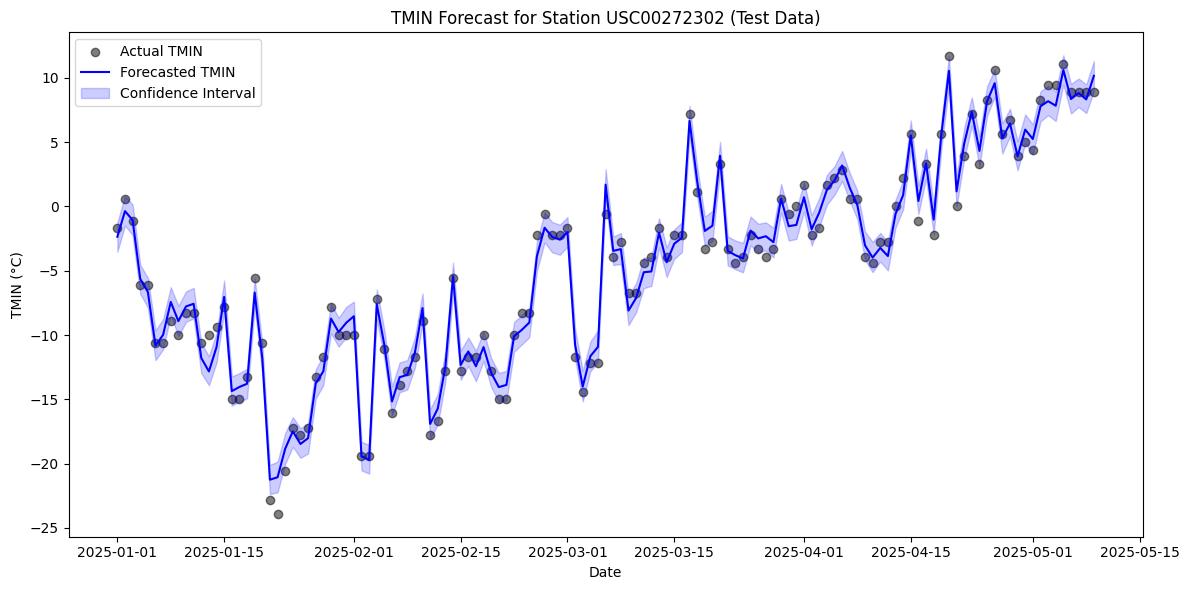


📈 Forecast Results for Station USC00279278 (Test Data):
        ds     y   yhat  yhat_lower  yhat_upper
2025-01-01  -1.1  -1.86       -2.97       -0.76
2025-01-02   1.1   0.09       -0.97        1.11
2025-01-03  -1.1  -0.02       -1.11        1.12
2025-01-04  -4.4  -3.65       -4.81       -2.51
2025-01-05  -7.2  -7.07       -8.15       -5.97
2025-01-06 -10.6 -10.53      -11.66       -9.36
2025-01-07 -10.6 -10.41      -11.54       -9.35
2025-01-08  -8.3  -7.29       -8.38       -6.14
2025-01-09 -10.6  -9.64      -10.74       -8.58
2025-01-10  -8.3  -8.83       -9.99       -7.68
2025-01-11  -5.6  -5.77       -6.91       -4.66
2025-01-12  -6.7  -8.89      -10.06       -7.79
2025-01-13  -8.3 -11.50      -12.61      -10.30
2025-01-14  -8.3  -9.67      -10.69       -8.54
2025-01-15  -7.2  -6.21       -7.28       -5.18
2025-01-16 -14.4 -13.63      -14.73      -12.48
2025-01-17 -12.8 -11.84      -12.99      -10.80
2025-01-18 -10.0 -10.10      -11.29       -8.97
2025-01-19  -3.3  -4.42       -

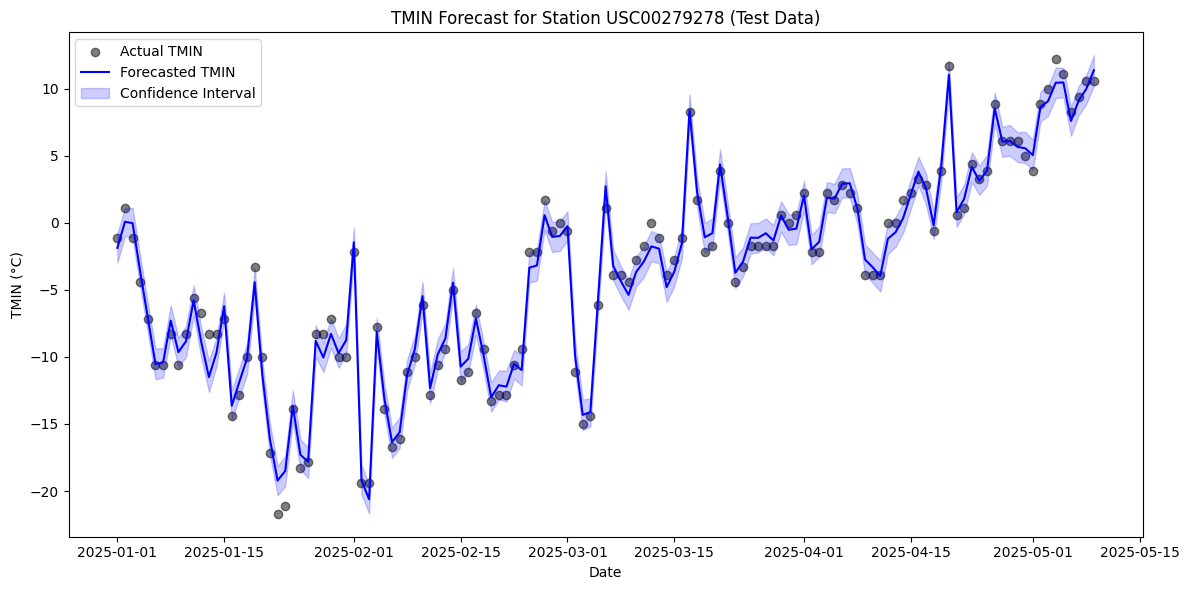


📈 Forecast Results for Station USC00278614 (Test Data):
        ds      y   yhat  yhat_lower  yhat_upper
2025-01-01  -2.80  -5.02       -6.17       -3.91
2025-01-02   0.60  -1.10       -2.29        0.07
2025-01-03  -2.20  -2.31       -3.41       -1.17
2025-01-04  -7.80  -7.81       -9.02       -6.63
2025-01-05  -8.30  -9.84      -10.92       -8.62
2025-01-06 -13.90 -14.98      -16.06      -13.86
2025-01-07 -12.80 -13.74      -14.94      -12.59
2025-01-08  -8.90  -8.06       -9.18       -6.89
2025-01-09 -10.60  -9.84      -10.95       -8.75
2025-01-10  -8.30  -8.96      -10.18       -7.74
2025-01-11  -6.70  -6.32       -7.58       -5.18
2025-01-12 -10.00 -11.61      -12.76      -10.41
2025-01-13 -10.00 -13.23      -14.37      -12.10
2025-01-14  -9.40 -10.84      -12.04       -9.77
2025-01-15  -7.80  -7.08       -8.17       -5.89
2025-01-16 -17.20 -16.29      -17.41      -15.20
2025-01-17 -17.20 -15.63      -16.80      -14.41
2025-01-18 -13.30 -12.22      -13.38      -11.03
2025-01-19  

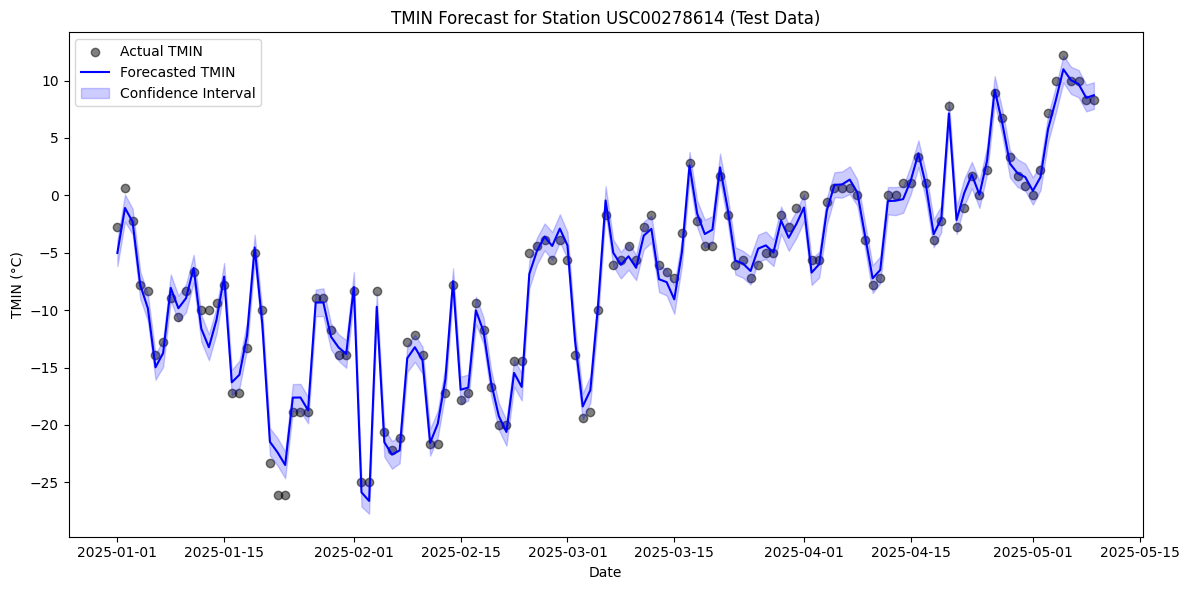


📈 Forecast Results for Station USC00275703 (Test Data):
        ds     y   yhat  yhat_lower  yhat_upper
2025-01-01  -2.2  -3.56       -5.09       -2.04
2025-01-02   0.6  -0.31       -1.86        1.33
2025-01-03  -1.7  -2.77       -4.35       -1.20
2025-01-04  -7.8  -9.55      -11.04       -7.90
2025-01-05  -6.7  -8.80      -10.38       -7.28
2025-01-06 -10.6 -10.37      -12.02       -9.02
2025-01-07 -11.7 -10.08      -11.70       -8.51
2025-01-08 -10.6  -7.37       -8.83       -5.90
2025-01-09 -11.1  -9.02      -10.58       -7.62
2025-01-10  -8.9  -9.30      -10.85       -7.76
2025-01-11  -6.7  -6.55       -8.15       -4.97
2025-01-12 -10.0 -11.43      -12.95       -9.86
2025-01-13 -10.6 -13.10      -14.55      -11.68
2025-01-14 -11.1 -11.16      -12.64       -9.61
2025-01-15  -7.8  -6.85       -8.32       -5.34
2025-01-16 -16.1 -14.93      -16.42      -13.36
2025-01-17 -16.1 -14.73      -16.13      -13.23
2025-01-18 -12.8 -12.75      -14.34      -11.25
2025-01-19  -4.4  -5.37       -

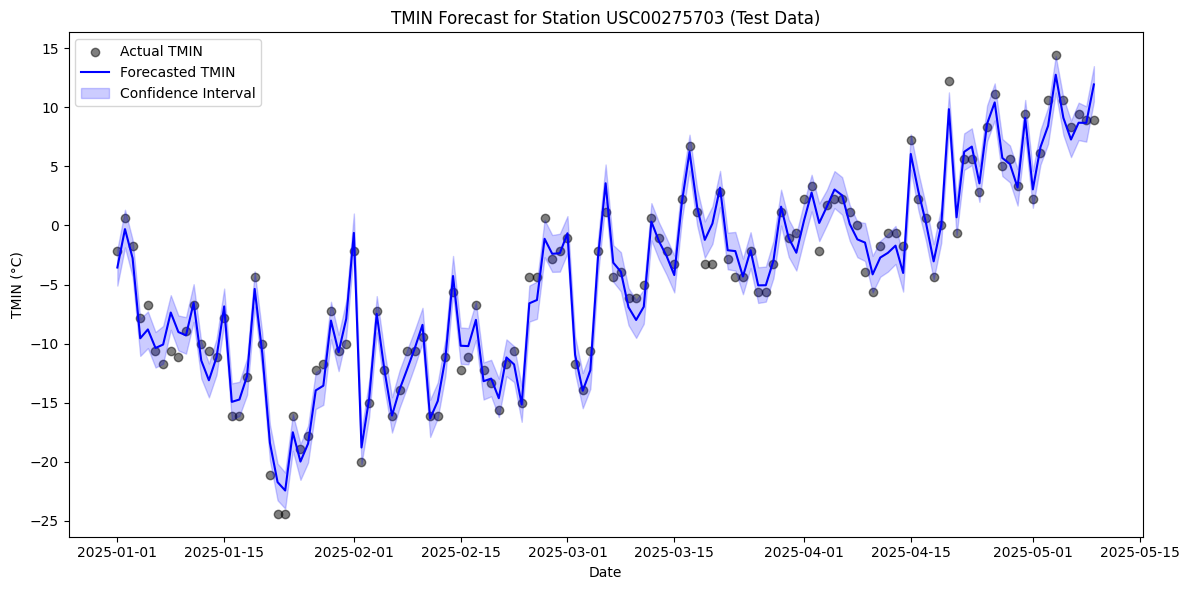


📈 Forecast Results for Station USW00014755 (Test Data):
        ds      y   yhat  yhat_lower  yhat_upper
2025-01-01  -7.20  -8.03       -8.89       -7.31
2025-01-02 -13.90 -14.20      -15.01      -13.37
2025-01-03 -17.80 -19.28      -20.07      -18.52
2025-01-04 -23.30 -24.51      -25.29      -23.73
2025-01-05 -23.90 -23.69      -24.43      -22.94
2025-01-06 -13.90 -14.34      -15.15      -13.58
2025-01-07 -24.40 -23.87      -24.65      -23.08
2025-01-08 -23.90 -22.86      -23.69      -22.06
2025-01-09 -24.40 -24.26      -25.04      -23.45
2025-01-10 -17.80 -17.45      -18.26      -16.66
2025-01-11 -11.70 -11.44      -12.22      -10.65
2025-01-12 -16.70 -17.30      -18.04      -16.47
2025-01-13 -13.30 -14.65      -15.42      -13.88
2025-01-14 -16.10 -16.57      -17.33      -15.77
2025-01-15 -22.20 -21.84      -22.61      -21.05
2025-01-16 -22.20 -21.07      -21.83      -20.29
2025-01-17 -20.00 -19.01      -19.80      -18.19
2025-01-18 -16.10 -16.04      -16.82      -15.29
2025-01-19 -

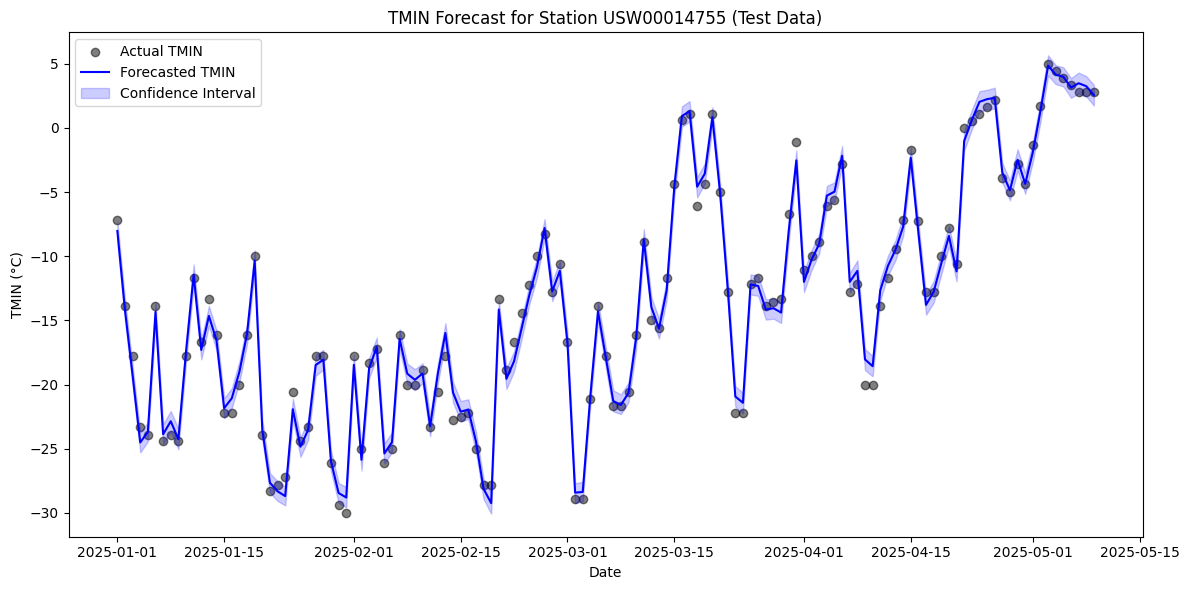

In [14]:
for station in ["USC00272302","USC00279278","USC00278614","USC00275703","USW00014755"]:
    forecaster.plot_station_forecast(station)

In [15]:
pip install keras-tuner


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import Input
import keras_tuner as kt
from keras_tuner import Objective
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
import multiprocessing
import os

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Load and filter data
data = pd.read_csv('/workspaces/BlizzardX/Data/feature_data.csv')
station_ids = data['Station_ID'].unique()
#station_id = 'USC00279278'
#data = data[data['Station_ID'] == station_id]

for station_id in station_ids:
    print(f"\n📍 Processing Station: {station_id}")
    station_data = data[data['Station_ID'] == station_id].copy()
    if len(station_data) < 200:
        print("⚠️ Skipped — not enough records.")
        continue


# Feature selection
initial_features = [
    'TMIN', 'TMAX', 'PRCP', 'SNOW', 'SNWD',
    'Rolling_Mean_TMIN_7', 'Rolling_Mean_TMIN_30', 'Seasonal_TMIN_Anomaly',
    'TMIN_Lag1', 'PRCP_Lag1', 'Cumulative_Precipitation_7',
    'Day_of_Year', 'Month'
]

#data = data.dropna().sort_values('DATE')
station_data = station_data.dropna().sort_values('DATE')
X_feat_check = station_data[initial_features]
y_feat_check = station_data['TMIN']
#X_feat_check = data[initial_features]
#y_feat_check = data['TMIN']

etr = ExtraTreesRegressor(n_estimators=100, random_state=42)
etr.fit(X_feat_check, y_feat_check)
importances = etr.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': initial_features,
    'Importance': importances,
    'Percentage': 100 * importances / importances.sum()
}).sort_values(by='Importance', ascending=False)

threshold_pct = 2
filtered_features = feature_importance_df[feature_importance_df['Percentage'] >= threshold_pct]['Feature'].tolist()
feature_columns = filtered_features

# Time features
data['DATE'] = pd.to_datetime(data['DATE'])
data = data.sort_values('DATE')
data['Year'] = data['DATE'].dt.year

max_date = data['DATE'].max()
max_year = max_date.year
train_data = data[data['Year'] <= max_year - 3]
val_data = data[data['Year'].isin([max_year - 2, max_year - 1])]
test_data = data[data['Year'] == max_year]

X_train = train_data[feature_columns].values
y_train = train_data['TMIN'].values
X_val = val_data[feature_columns].values
y_val = val_data['TMIN'].values
X_test = test_data[feature_columns].values
y_test = test_data['TMIN'].values

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

def create_sequences(X, y, seq_length):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X[i:i+seq_length])
        ys.append(y[i+seq_length])
    return np.array(Xs), np.array(ys)

seq_length = 14
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, seq_length)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, seq_length)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, seq_length)

batch_size = 16
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_seq, y_train_seq)).shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val_seq, y_val_seq)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test_seq, y_test_seq)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Hypermodel
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(seq_length, len(feature_columns))))

    for i in range(hp.Int("num_lstm_layers", 1, 3)):
        model.add(LSTM(units=hp.Int(f"lstm_units_{i}", min_value=32, max_value=150, step=32), return_sequences=(i != hp.get("num_lstm_layers") - 1)))
        model.add(Dropout(rate=hp.Float(f"dropout_{i}", 0.1, 0.3, step=0.05)))

    model.add(Dense(units=hp.Int("dense_units", 32, 128, step=32), activation="relu"))
    model.add(Dense(1))

    model.compile(optimizer=tf.keras.optimizers.Adam(hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])),
                  loss="mse",
                  metrics=["mae"])
    return model



tuner = kt.BayesianOptimization(
    hypermodel=build_model,
    objective=Objective("val_loss", direction="min"),
    max_trials=10,
    executions_per_trial=1,
    directory="lstm_tuner_weather",
    project_name="tuning_run_30min",
    overwrite=True
)

tuner.search(train_dataset,
             validation_data=val_dataset,
             epochs=30,
             callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
             verbose=1)

best_model = tuner.get_best_models(num_models=1)[0]
eval_results = best_model.evaluate(test_dataset)
print("📊 Test evaluation:", dict(zip(best_model.metrics_names, eval_results)))


Trial 2 Complete [00h 16m 31s]
val_loss: 0.12577787041664124

Best val_loss So Far: 0.12577787041664124
Total elapsed time: 00h 29m 32s

Search: Running Trial #3

Value             |Best Value So Far |Hyperparameter
1                 |3                 |num_lstm_layers
96                |64                |lstm_units_0


0.1               |0.2               |dropout_0
32                |128               |dense_units
0.0001            |0.001             |learning_rate
64                |128               |lstm_units_1
0.2               |0.25              |dropout_1
96                |32                |lstm_units_2
0.2               |0.1               |dropout_2

Epoch 1/30
3106/3106 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 0.2515 - mae: 0.3825 - val_loss: 0.1465 - val_mae: 0.2935
Epoch 2/30
3106/3106 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 0.1807 - mae: 0.3285 - val_loss: 0.1430 - val_mae: 0.2889
Epoch 3/30
 459/3106 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 0.1725 - mae: 0.3211

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Input
import keras_tuner as kt
from keras_tuner import Objective
import matplotlib.pyplot as plt
import os

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Load data
results = []
data = pd.read_csv('/workspaces/BlizzardX/Data/feature_data.csv')
station_ids = data['Station_ID'].unique()

# Loop through each station
for station_id in station_ids:
    print(f"\n📍 Processing Station: {station_id}")
    station_data = data[data['Station_ID'] == station_id].copy()
    if len(station_data) < 200:
        print("⚠️ Skipped — not enough records.")
        continue

    # Feature selection
    initial_features = [
        'TMIN', 'TMAX', 'PRCP', 'SNOW', 'SNWD',
        'Rolling_Mean_TMIN_7', 'Rolling_Mean_TMIN_30', 'Seasonal_TMIN_Anomaly',
        'TMIN_Lag1', 'PRCP_Lag1', 'Cumulative_Precipitation_7',
        'Day_of_Year', 'Month'
    ]

    station_data = station_data.dropna().sort_values('DATE')
    X_feat_check = station_data[initial_features]
    y_feat_check = station_data['TMIN']

    etr = ExtraTreesRegressor(n_estimators=100, random_state=42)
    etr.fit(X_feat_check, y_feat_check)
    importances = etr.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': initial_features,
        'Importance': importances,
        'Percentage': 100 * importances / importances.sum()
    }).sort_values(by='Importance', ascending=False)

    threshold_pct = 2
    filtered_features = feature_importance_df[feature_importance_df['Percentage'] >= threshold_pct]['Feature'].tolist()
    feature_columns = filtered_features

    # Time features
    station_data['DATE'] = pd.to_datetime(station_data['DATE'])
    station_data = station_data.sort_values('DATE')
    station_data['Year'] = station_data['DATE'].dt.year

    max_date = station_data['DATE'].max()
    max_year = max_date.year
    train_data = station_data[station_data['Year'] <= max_year - 3]
    val_data = station_data[station_data['Year'].isin([max_year - 2, max_year - 1])]
    test_data = station_data[station_data['Year'] == max_year]

    X_train = train_data[feature_columns].values
    y_train = train_data['TMIN'].values
    X_val = val_data[feature_columns].values
    y_val = val_data['TMIN'].values
    X_test = test_data[feature_columns].values
    y_test = test_data['TMIN'].values

    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_val_scaled = scaler_X.transform(X_val)
    X_test_scaled = scaler_X.transform(X_test)

    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).flatten()
    y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

    def create_sequences(X, y, seq_length):
        Xs, ys = [], []
        for i in range(len(X) - seq_length):
            Xs.append(X[i:i+seq_length])
            ys.append(y[i+seq_length])
        return np.array(Xs), np.array(ys)

    seq_length = 14
    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, seq_length)
    X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, seq_length)
    X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, seq_length)

    batch_size = 16
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train_seq, y_train_seq)).shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_dataset = tf.data.Dataset.from_tensor_slices((X_val_seq, y_val_seq)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    test_dataset = tf.data.Dataset.from_tensor_slices((X_test_seq, y_test_seq)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    # Hypermodel
    def build_model(hp):
        model = Sequential()
        model.add(Input(shape=(seq_length, len(feature_columns))))

        for i in range(hp.Int("num_lstm_layers", 1, 3)):
            model.add(LSTM(units=hp.Int(f"lstm_units_{i}", min_value=32, max_value=150, step=32), return_sequences=(i != hp.get("num_lstm_layers") - 1)))
            model.add(Dropout(rate=hp.Float(f"dropout_{i}", 0.1, 0.3, step=0.05)))

        model.add(Dense(units=hp.Int("dense_units", 32, 128, step=32), activation="relu"))
        model.add(Dense(1))

        model.compile(optimizer=tf.keras.optimizers.Adam(hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])),
                      loss="mse",
                      metrics=["mae"])
        return model

    tuner = kt.BayesianOptimization(
        hypermodel=build_model,
        objective=Objective("val_loss", direction="min"),
        max_trials=5,
        executions_per_trial=1,
        directory="lstm_tuner_weather",
        project_name=f"tuning_{station_id}",
        overwrite=True
    )

    tuner.search(train_dataset,
                 validation_data=val_dataset,
                 epochs=20,
                 callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
                 verbose=0)

    best_model = tuner.get_best_models(num_models=1)[0]
    eval_results = best_model.evaluate(test_dataset, verbose=0)
    results.append({
        'Station_ID': station_id,
        'MAE': eval_results[1],
        'RMSE': np.sqrt(eval_results[0])
    })

# Save all station results
results_df = pd.DataFrame(results)
results_df.to_csv('/workspaces/BlizzardX/Results/lstm_all_station_results.csv', index=False)
print("✅ All station results saved.")



📍 Processing Station: USW00014755


2025-04-24 17:47:20.262849: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 21461216 exceeds 10% of free system memory.
2025-04-24 17:47:20.857982: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 21461216 exceeds 10% of free system memory.
/home/codespace/.local/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 28 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



📍 Processing Station: USC00278614


/home/codespace/.local/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 28 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



📍 Processing Station: USC00279278


...


📍 Processing Station: USC00272302


/home/codespace/.local/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



📍 Processing Station: USC00275703


/home/codespace/.local/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


OSError: Cannot save file into a non-existent directory: '/workspaces/BlizzardX/Results'

In [ ]:
os.makedirs('/workspaces/BlizzardX/Results', exist_ok=True)

In [ ]:
# Save all station results
os.makedirs('/workspaces/BlizzardX/Results', exist_ok=True)
results_df = pd.DataFrame(results)
results_df.to_csv('/workspaces/BlizzardX/Results/lstm_all_station_results.csv', index=False)
print("✅ All station results saved.")

✅ All station results saved.


In [ ]:
import matplotlib.pyplot as plt

# Predict on test set and inverse transform
y_pred_scaled = best_model.predict(X_test_seq)
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_true = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(y_true, label='Actual TMIN', color='blue')
plt.plot(y_pred, label='Predicted TMIN', color='green', linestyle='--')
plt.title(f'Station: {station_id} - Actual vs Predicted TMIN')
plt.xlabel('Time Step')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()

# Save figure
os.makedirs(f'/workspaces/BlizzardX/Results/Plots', exist_ok=True)
plt.savefig(f'/workspaces/BlizzardX/Results/Plots/{station_id}_TMIN_Plot.png')
plt.close()


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 275ms/step


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Input
import keras_tuner as kt
from keras_tuner import Objective
import matplotlib.pyplot as plt
import os

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Load data
results = []
data = pd.read_csv('/workspaces/BlizzardX/Data/feature_data.csv')
station_ids = data['Station_ID'].unique()

# Forecast function
def forecast_lstm(model, last_seq, n_days, scaler_y):
    preds = []
    current_seq = last_seq.copy()
    for _ in range(n_days):
        pred_scaled = model.predict(current_seq[np.newaxis, :, :])[0, 0]
        pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
        preds.append(pred)
        next_input = current_seq[1:]
        next_input = np.vstack([next_input, current_seq[-1]])
        next_input[-1][0] = pred_scaled  # Update TMIN in last row
        current_seq = next_input
    return np.array(preds)

# Loop through each station
for station_id in station_ids:
    print(f"\n📍 Processing Station: {station_id}")
    station_data = data[data['Station_ID'] == station_id].copy()
    if len(station_data) < 200:
        print("⚠️ Skipped — not enough records.")
        continue

    # Feature selection
    initial_features = [
        'TMIN', 'TMAX', 'PRCP', 'SNOW', 'SNWD',
        'Rolling_Mean_TMIN_7', 'Rolling_Mean_TMIN_30', 'Seasonal_TMIN_Anomaly',
        'TMIN_Lag1', 'PRCP_Lag1', 'Cumulative_Precipitation_7',
        'Day_of_Year', 'Month'
    ]

    station_data = station_data.dropna().sort_values('DATE')
    X_feat_check = station_data[initial_features]
    y_feat_check = station_data['TMIN']

    etr = ExtraTreesRegressor(n_estimators=100, random_state=42)
    etr.fit(X_feat_check, y_feat_check)
    importances = etr.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': initial_features,
        'Importance': importances,
        'Percentage': 100 * importances / importances.sum()
    }).sort_values(by='Importance', ascending=False)

    threshold_pct = 2
    filtered_features = feature_importance_df[feature_importance_df['Percentage'] >= threshold_pct]['Feature'].tolist()
    feature_columns = filtered_features

    # Time features
    station_data['DATE'] = pd.to_datetime(station_data['DATE'])
    station_data = station_data.sort_values('DATE')
    station_data['Year'] = station_data['DATE'].dt.year

    max_date = station_data['DATE'].max()
    max_year = max_date.year
    train_data = station_data[station_data['Year'] <= max_year - 3]
    val_data = station_data[station_data['Year'].isin([max_year - 2, max_year - 1])]
    test_data = station_data[station_data['Year'] == max_year]

    X_train = train_data[feature_columns].values
    y_train = train_data['TMIN'].values
    X_val = val_data[feature_columns].values
    y_val = val_data['TMIN'].values
    X_test = test_data[feature_columns].values
    y_test = test_data['TMIN'].values

    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_val_scaled = scaler_X.transform(X_val)
    X_test_scaled = scaler_X.transform(X_test)

    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).flatten()
    y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

    def create_sequences(X, y, seq_length):
        Xs, ys = [], []
        for i in range(len(X) - seq_length):
            Xs.append(X[i:i+seq_length])
            ys.append(y[i+seq_length])
        return np.array(Xs), np.array(ys)

    seq_length = 14
    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, seq_length)
    X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, seq_length)
    X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, seq_length)

    batch_size = 16
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train_seq, y_train_seq)).shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_dataset = tf.data.Dataset.from_tensor_slices((X_val_seq, y_val_seq)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    test_dataset = tf.data.Dataset.from_tensor_slices((X_test_seq, y_test_seq)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    # Hypermodel
    def build_model(hp):
        model = Sequential()
        model.add(Input(shape=(seq_length, len(feature_columns))))

        for i in range(hp.Int("num_lstm_layers", 1, 3)):
            model.add(LSTM(units=hp.Int(f"lstm_units_{i}", min_value=32, max_value=150, step=32), return_sequences=(i != hp.get("num_lstm_layers") - 1)))
            model.add(Dropout(rate=hp.Float(f"dropout_{i}", 0.1, 0.3, step=0.05)))

        model.add(Dense(units=hp.Int("dense_units", 32, 128, step=32), activation="relu"))
        model.add(Dense(1))

        model.compile(optimizer=tf.keras.optimizers.Adam(hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])),
                      loss="mse",
                      metrics=["mae"])
        return model

    tuner = kt.BayesianOptimization(
        hypermodel=build_model,
        objective=Objective("val_loss", direction="min"),
        max_trials=5,
        executions_per_trial=1,
        directory="lstm_tuner_weather",
        project_name=f"tuning_{station_id}",
        overwrite=True
    )

    tuner.search(train_dataset,
                 validation_data=val_dataset,
                 epochs=20,
                 callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
                 verbose=0)

    best_model = tuner.get_best_models(num_models=1)[0]
    eval_results = best_model.evaluate(test_dataset, verbose=0)

    # Get forecast
    last_seq = X_test_seq[-1]
    forecasted_tmin = forecast_lstm(best_model, last_seq, 7, scaler_y)

    os.makedirs(f'/workspaces/BlizzardX/Results/Forecasts', exist_ok=True)
    forecast_df = pd.DataFrame({
        'Day': [f'Day {i+1}' for i in range(7)],
        'Forecasted_TMIN': forecasted_tmin
    })
    forecast_df.to_csv(f'/workspaces/BlizzardX/Results/Forecasts/{station_id}_7day_forecast.csv', index=False)

    # Plot actual vs predicted
    y_pred_scaled = best_model.predict(X_test_seq)
    y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
    y_true = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

    plt.figure(figsize=(12, 6))
    plt.plot(y_true, label='Actual TMIN', color='blue')
    plt.plot(y_pred, label='Predicted TMIN', color='green', linestyle='--')
    plt.title(f'Station: {station_id} - Actual vs Predicted TMIN')
    plt.xlabel('Time Step')
    plt.ylabel('Temperature (°C)')
    plt.legend()
    plt.tight_layout()
    os.makedirs(f'/workspaces/BlizzardX/Results/Plots', exist_ok=True)
    plt.savefig(f'/workspaces/BlizzardX/Results/Plots/{station_id}_TMIN_Plot.png')
    plt.close()

    # Final metrics and logging
    test_mae = eval_results[1]
    test_rmse = np.sqrt(eval_results[0])
    val_loss = tuner.oracle.get_best_trials(num_trials=1)[0].score
    sample_count = len(y_test_seq)

    results.append({
        'Station_ID': station_id,
        'MAE': test_mae,
        'RMSE': test_rmse,
        'Val_Loss': val_loss,
        'Test_Sample_Count': sample_count,
        'Top_Features': ', '.join(feature_columns[:5])
    })

# Save results
os.makedirs('/workspaces/BlizzardX/Results', exist_ok=True)
results_df = pd.DataFrame(results)
results_df.to_csv('/workspaces/BlizzardX/Results/lstm_all_station_results.csv', index=False)
print("✅ All station results saved.")



📍 Processing Station: USW00014755


2025-04-24 18:49:27.374114: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 21461216 exceeds 10% of free system memory.
/home/codespace/.local/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step 

📍 Processing Station: USC00278614


/home/codespace/.local/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step 

📍 Processing Station: USC00279278


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step 

📍 Processing Station: USC00272302


/home/codespace/.local/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step 

📍 Processing Station: USC00275703


/home/codespace/.local/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 
✅ All station results saved.


In [ ]:
# Multi-Station LSTM Forecasting for SNOW

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import StandardScaler
import keras_tuner as kt
from keras_tuner import Objective

# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

# Paths
DATA_PATH = "/workspaces/BlizzardX/Data/feature_data.csv"
PLOT_DIR = "/workspaces/BlizzardX/Results/Plots"
FORECAST_DIR = "/workspaces/BlizzardX/Results/Forecasts"
RESULT_PATH = "/workspaces/BlizzardX/Results/lstm_all_station_snow_results.csv"
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(FORECAST_DIR, exist_ok=True)

# Load data
df = pd.read_csv(DATA_PATH)
df['DATE'] = pd.to_datetime(df['DATE'])
df['Year'] = df['DATE'].dt.year

results = []
station_ids = df['Station_ID'].unique()

for station_id in station_ids:
    station_df = df[df['Station_ID'] == station_id].dropna()

    # Feature selection
    initial_features = [
        'TMIN', 'TMAX', 'PRCP', 'SNOW', 'SNWD',
        'Rolling_Mean_SNOW_7', 'SNOW_Lag1',
        'Day_of_Year', 'Month'
    ]
    X_feat_check = station_df[initial_features]
    y_feat_check = station_df['SNOW']

    etr = ExtraTreesRegressor(n_estimators=100, random_state=42)
    etr.fit(X_feat_check, y_feat_check)
    importances = etr.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': initial_features,
        'Importance': importances,
        'Percentage': 100 * importances / importances.sum()
    }).sort_values(by='Importance', ascending=False)

    feature_columns = feature_importance_df[feature_importance_df['Percentage'] > 2]['Feature'].tolist()
    data = station_df.sort_values('DATE')

    # Train/Val/Test split
    max_year = data['Year'].max()
    train = data[data['Year'] <= max_year - 3]
    val = data[data['Year'].isin([max_year - 2, max_year - 1])]
    test = data[data['Year'] == max_year]

    X_train = train[feature_columns].values
    y_train = train['SNOW'].values
    X_val = val[feature_columns].values
    y_val = val['SNOW'].values
    X_test = test[feature_columns].values
    y_test = test['SNOW'].values

    # Scale
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_train = scaler_X.fit_transform(X_train)
    X_val = scaler_X.transform(X_val)
    X_test = scaler_X.transform(X_test)
    y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_val = scaler_y.transform(y_val.reshape(-1, 1)).flatten()
    y_test = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

    def create_sequences(X, y, seq_length):
        Xs, ys = [], []
        for i in range(len(X) - seq_length):
            Xs.append(X[i:i+seq_length])
            ys.append(y[i+seq_length])
        return np.array(Xs), np.array(ys)

    seq_length = 14
    X_train_seq, y_train_seq = create_sequences(X_train, y_train, seq_length)
    X_val_seq, y_val_seq = create_sequences(X_val, y_val, seq_length)
    X_test_seq, y_test_seq = create_sequences(X_test, y_test, seq_length)

    train_dataset = tf.data.Dataset.from_tensor_slices((X_train_seq, y_train_seq)).shuffle(1000).batch(16).prefetch(tf.data.AUTOTUNE)
    val_dataset = tf.data.Dataset.from_tensor_slices((X_val_seq, y_val_seq)).batch(16).prefetch(tf.data.AUTOTUNE)
    test_dataset = tf.data.Dataset.from_tensor_slices((X_test_seq, y_test_seq)).batch(16).prefetch(tf.data.AUTOTUNE)

    def build_model(hp):
        model = Sequential()
        model.add(Input(shape=(seq_length, len(feature_columns))))
        for i in range(hp.Int("num_lstm_layers", 1, 2)):
            model.add(LSTM(units=hp.Int(f"lstm_units_{i}", 32, 128, step=32), return_sequences=(i != hp.get("num_lstm_layers") - 1)))
            model.add(Dropout(rate=hp.Float(f"dropout_{i}", 0.1, 0.3, step=0.1)))
        model.add(Dense(1))
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss="mse", metrics=["mae"])
        return model

    tuner = kt.BayesianOptimization(build_model, objective=Objective("val_loss", direction="min"), max_trials=5, directory="tuner_snow", project_name=f"snow_{station_id}", overwrite=True)
    tuner.search(train_dataset, validation_data=val_dataset, epochs=20, callbacks=[EarlyStopping(patience=5)], verbose=0)
    best_model = tuner.get_best_models(1)[0]
    eval_results = best_model.evaluate(test_dataset, verbose=0)

    # Forecast
    def forecast_next_days(model, last_seq, n_days):
        predictions = []
        input_seq = last_seq.copy()
        for _ in range(n_days):
            pred = model.predict(np.expand_dims(input_seq, axis=0), verbose=0)[0][0]
            predictions.append(pred)
            input_seq = np.append(input_seq[1:], [np.append(input_seq[-1][1:], pred)], axis=0)
        return scaler_y.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()

    last_seq = X_test_seq[-1]
    forecasted_snow = forecast_next_days(best_model, last_seq, 7)
    forecast_df = pd.DataFrame({"Day": [f"Day {i+1}" for i in range(7)], "Forecasted_SNOW": forecasted_snow})
    forecast_df.to_csv(os.path.join(FORECAST_DIR, f"{station_id}_7day_snow_forecast.csv"), index=False)

    # Plot
    y_pred = scaler_y.inverse_transform(best_model.predict(X_test_seq, verbose=0).flatten().reshape(-1, 1)).flatten()
    y_true = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

    plt.figure(figsize=(12, 6))
    plt.plot(y_true, label="Actual SNOW", color='blue')
    plt.plot(y_pred, label="Predicted SNOW", color='green', linestyle='dashed')
    plt.title(f"Station: {station_id} - Actual vs Predicted SNOW")
    plt.xlabel("Time Step")
    plt.ylabel("Snowfall (mm)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"{station_id}_SNOW_Plot.png"))
    plt.close()

    # Record
    results.append({
        "Station_ID": station_id,
        "MAE": float(np.mean(np.abs(y_true - y_pred))),
        "RMSE": float(np.sqrt(np.mean((y_true - y_pred)**2))),
        "Val_Loss": float(eval_results[0]),
        "Test_Sample_Count": len(y_true),
        "Top_Features": ", ".join(feature_columns)
    })

# Final CSV
pd.DataFrame(results).to_csv(RESULT_PATH, index=False)
print("✅ Multi-station SNOW forecasting complete.")


/home/codespace/.local/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/codespace/.local/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/codespace/.local/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/codespace/.local/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam',

✅ Multi-station SNOW forecasting complete.


In [ ]:
# XGBoost Forecasting for TMIN and SNOW per Station

import pandas as pd
import numpy as np
import os
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Setup
DATA_PATH = "/workspaces/BlizzardX/Data/feature_data.csv"
RESULT_PATH = "/workspaces/BlizzardX/Results/xgb_all_station_results.csv"
PLOT_DIR = "/workspaces/BlizzardX/Results/Plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# Load data
df = pd.read_csv(DATA_PATH)
df['DATE'] = pd.to_datetime(df['DATE'])
df['Year'] = df['DATE'].dt.year

results = []
station_ids = df['Station_ID'].unique()

# Variables to model
targets = ["TMIN", "SNOW"]

for target in targets:
    print(f"\n📌 Target: {target}")

    for station_id in station_ids:
        station_df = df[df['Station_ID'] == station_id].dropna()
        if len(station_df) < 200:
            continue

        # Define target-specific features
        if target == "TMIN":
            features = [
                'TMIN', 'TMAX', 'PRCP', 'SNOW', 'SNWD',
                'Rolling_Mean_TMIN_7', 'Rolling_Mean_TMIN_30', 'Seasonal_TMIN_Anomaly',
                'TMIN_Lag1', 'PRCP_Lag1', 'Cumulative_Precipitation_7',
                'Day_of_Year', 'Month'
            ]
        else:  # SNOW
            features = [
                'TMIN', 'TMAX', 'PRCP', 'SNOW', 'SNWD',
                'Rolling_Mean_SNOW_7', 'SNOW_Lag1', 'Day_of_Year', 'Month'
            ]

        station_df = station_df.sort_values('DATE')
        max_year = station_df['Year'].max()

        train = station_df[station_df['Year'] <= max_year - 3]
        val = station_df[station_df['Year'].isin([max_year - 2, max_year - 1])]
        test = station_df[station_df['Year'] == max_year]

        X_train, y_train = train[features], train[target]
        X_test, y_test = test[features], test[target]

        # Scale
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        X_train_scaled = scaler_X.fit_transform(X_train)
        X_test_scaled = scaler_X.transform(X_test)
        y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()

        # Fit XGBoost
        model = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
        model.fit(X_train_scaled, y_train_scaled)

        # Predict and inverse scale
        y_pred_scaled = model.predict(X_test_scaled)
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        y_actual = y_test.values

        # Metrics
        mae = mean_absolute_error(y_actual, y_pred)
        rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

        # Save plot
        plt.figure(figsize=(12, 6))
        plt.plot(y_actual, label='Actual', color='blue')
        plt.plot(y_pred, label='Predicted', color='red', linestyle='--')
        plt.title(f"{target} - Station {station_id} - XGBoost")
        plt.xlabel("Time Step")
        plt.ylabel(target)
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"{PLOT_DIR}/{station_id}_{target}_XGB.png")
        plt.close()

        # Record
        results.append({
            "Station_ID": station_id,
            "Target": target,
            "MAE": mae,
            "RMSE": rmse,
            "Model": "XGBoost",
            "Test_Sample_Count": len(y_actual)
        })

# Save results
results_df = pd.DataFrame(results)
results_df.to_csv(RESULT_PATH, index=False)
print("✅ XGBoost results saved.")



📌 Target: TMIN

📌 Target: SNOW
✅ XGBoost results saved.


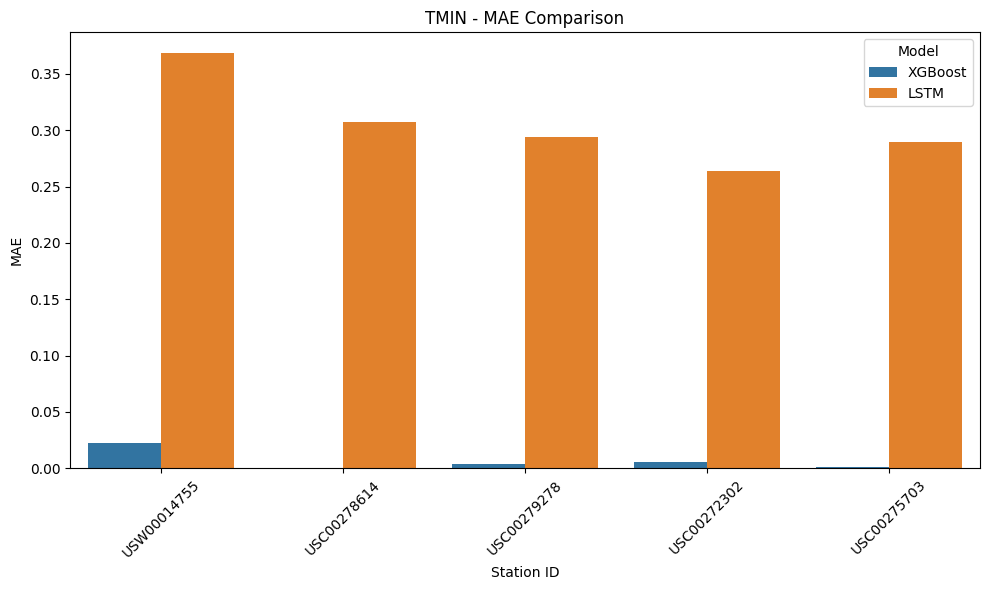

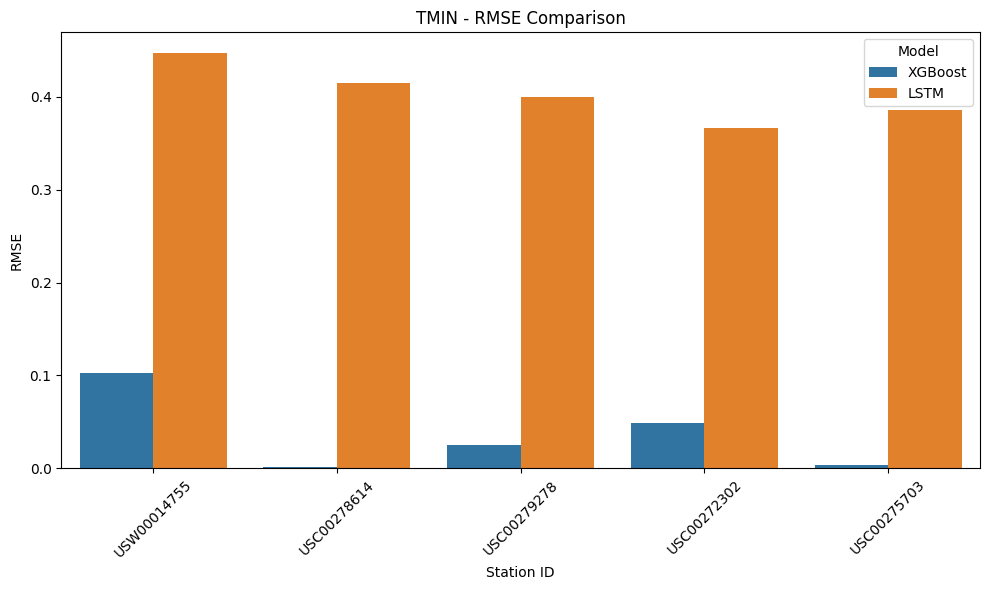

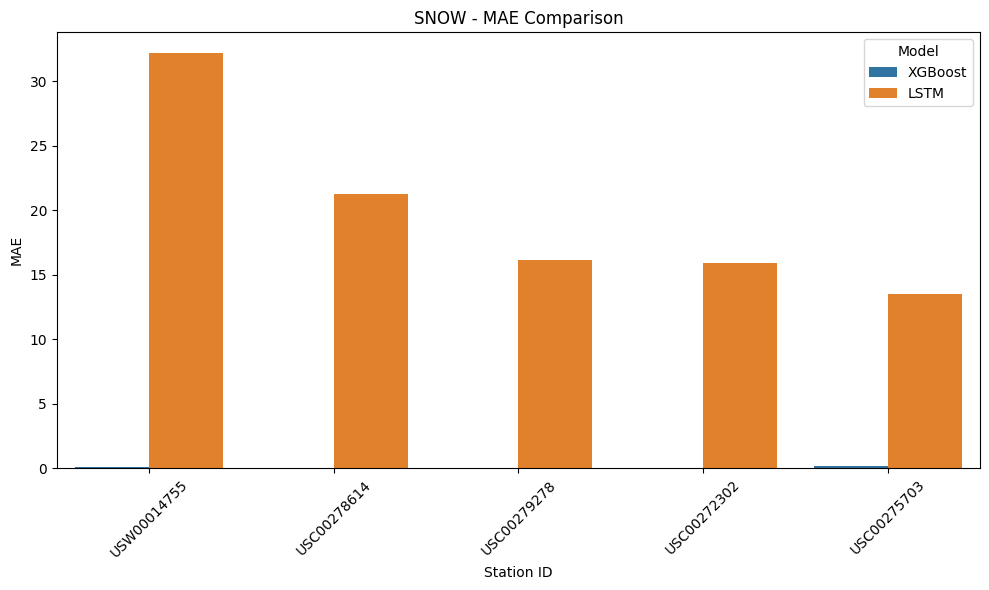

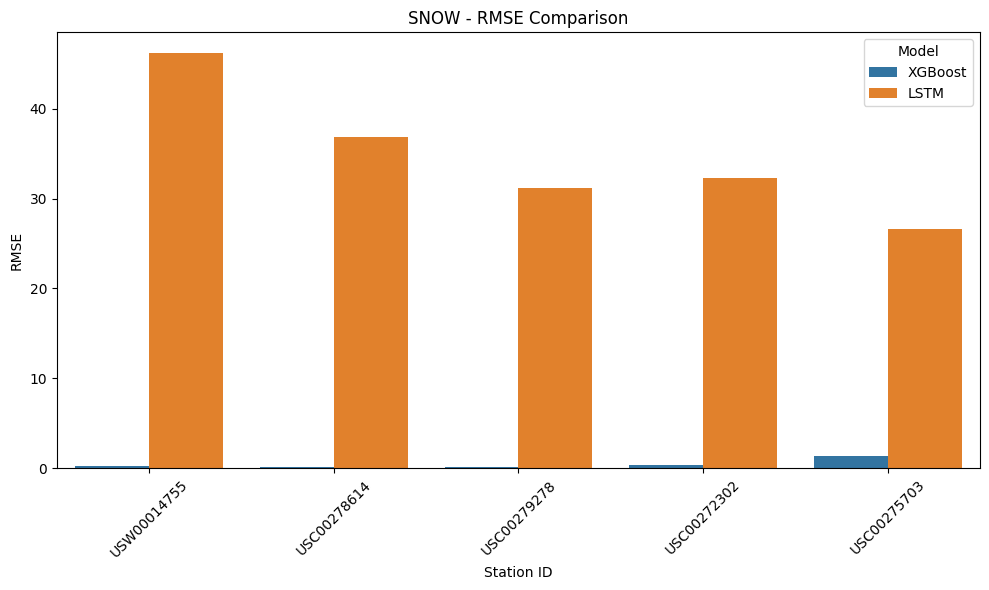

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load results
xgb = pd.read_csv('/workspaces/BlizzardX/Results/xgb_all_station_results.csv')
lstm_tmin = pd.read_csv('/workspaces/BlizzardX/Results/lstm_all_station_results.csv')
lstm_snow = pd.read_csv('/workspaces/BlizzardX/Results/lstm_all_station_snow_results.csv')

# Split XGB results by target
xgb_tmin = xgb[xgb['Target'] == 'TMIN'].copy()
xgb_snow = xgb[xgb['Target'] == 'SNOW'].copy()

# Add model labels
xgb_tmin['Model'] = 'XGBoost'
xgb_snow['Model'] = 'XGBoost'
lstm_tmin['Model'] = 'LSTM'
lstm_snow['Model'] = 'LSTM'

# Align columns
lstm_tmin['Target'] = 'TMIN'
lstm_snow['Target'] = 'SNOW'

# Combine for comparison
tmin_combined = pd.concat([xgb_tmin[['Station_ID', 'MAE', 'RMSE', 'Model']], lstm_tmin[['Station_ID', 'MAE', 'RMSE', 'Model']]])
snow_combined = pd.concat([xgb_snow[['Station_ID', 'MAE', 'RMSE', 'Model']], lstm_snow[['Station_ID', 'MAE', 'RMSE', 'Model']]])

# Plot function
def plot_comparison(df, metric, target):
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x='Station_ID', y=metric, hue='Model')
    plt.title(f'{target} - {metric} Comparison')
    plt.ylabel(metric)
    plt.xlabel('Station ID')
    plt.legend(title='Model')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Plot TMIN
plot_comparison(tmin_combined, 'MAE', 'TMIN')
plot_comparison(tmin_combined, 'RMSE', 'TMIN')

# Plot SNOW
plot_comparison(snow_combined, 'MAE', 'SNOW')
plot_comparison(snow_combined, 'RMSE', 'SNOW')


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load results
xgb_df = pd.read_csv("/workspaces/BlizzardX/Results/xgb_all_station_results.csv")  # Update path if needed

# Quick check
print(xgb_df.head())


    Station_ID Target       MAE      RMSE    Model  Test_Sample_Count
0  USW00014755   TMIN  0.022220  0.103063  XGBoost                105
1  USC00278614   TMIN  0.000399  0.000855  XGBoost                105
2  USC00279278   TMIN  0.003511  0.024968  XGBoost                105
3  USC00272302   TMIN  0.005341  0.048673  XGBoost                105
4  USC00275703   TMIN  0.000892  0.003026  XGBoost                105


/tmp/ipykernel_2092/2253315675.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=xgb_df, x='Target', y='MAE', palette='Set2')
/home/codespace/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


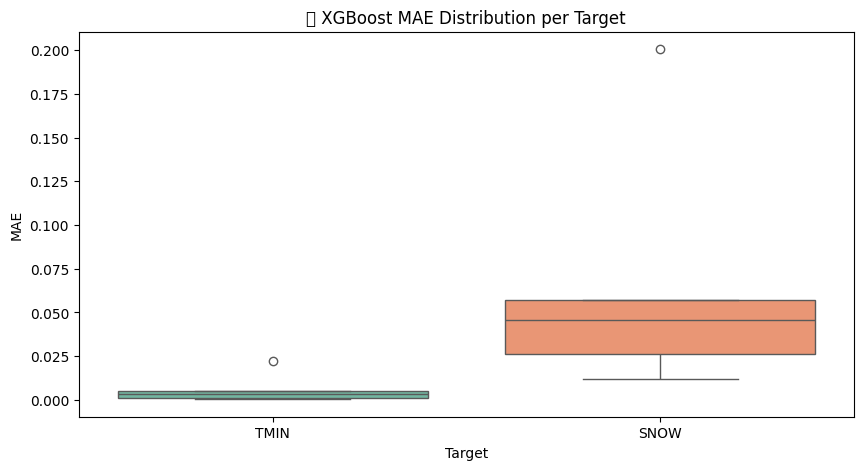

/tmp/ipykernel_2092/2253315675.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=xgb_df, x='Target', y='RMSE', palette='Set1')
/home/codespace/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


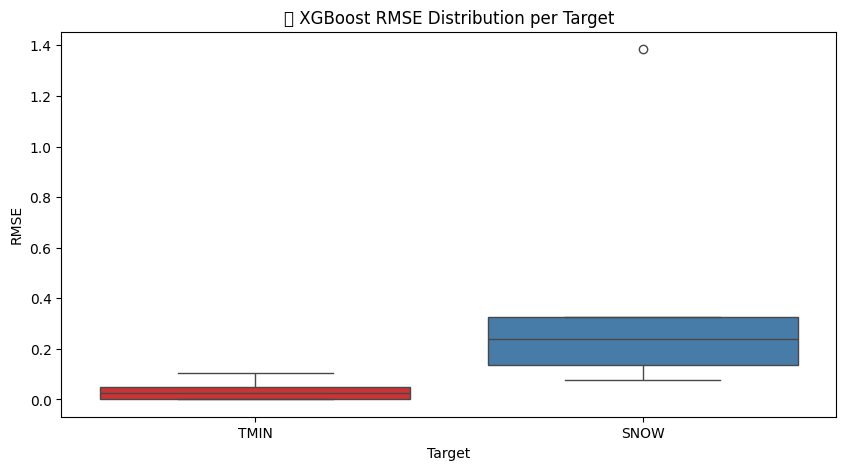

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=xgb_df, x='Target', y='MAE', palette='Set2')
plt.title("📊 XGBoost MAE Distribution per Target")
plt.ylabel("MAE")
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=xgb_df, x='Target', y='RMSE', palette='Set1')
plt.title("📊 XGBoost RMSE Distribution per Target")
plt.ylabel("RMSE")
plt.show()


/tmp/ipykernel_2092/237789114.py:6: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/codespace/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


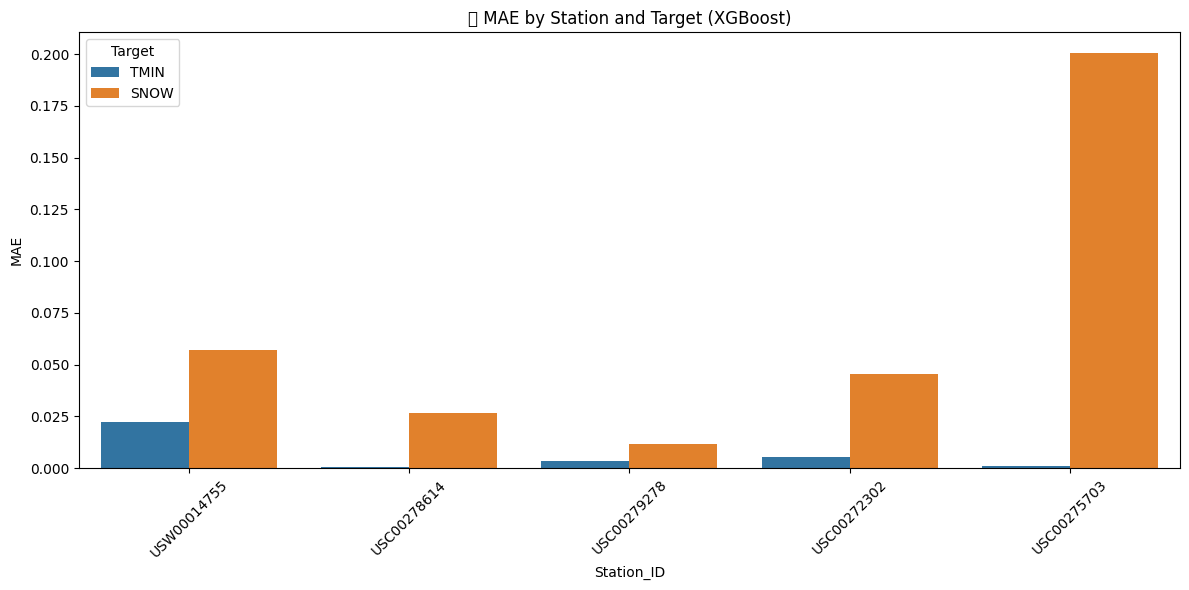

/tmp/ipykernel_2092/237789114.py:6: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/codespace/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


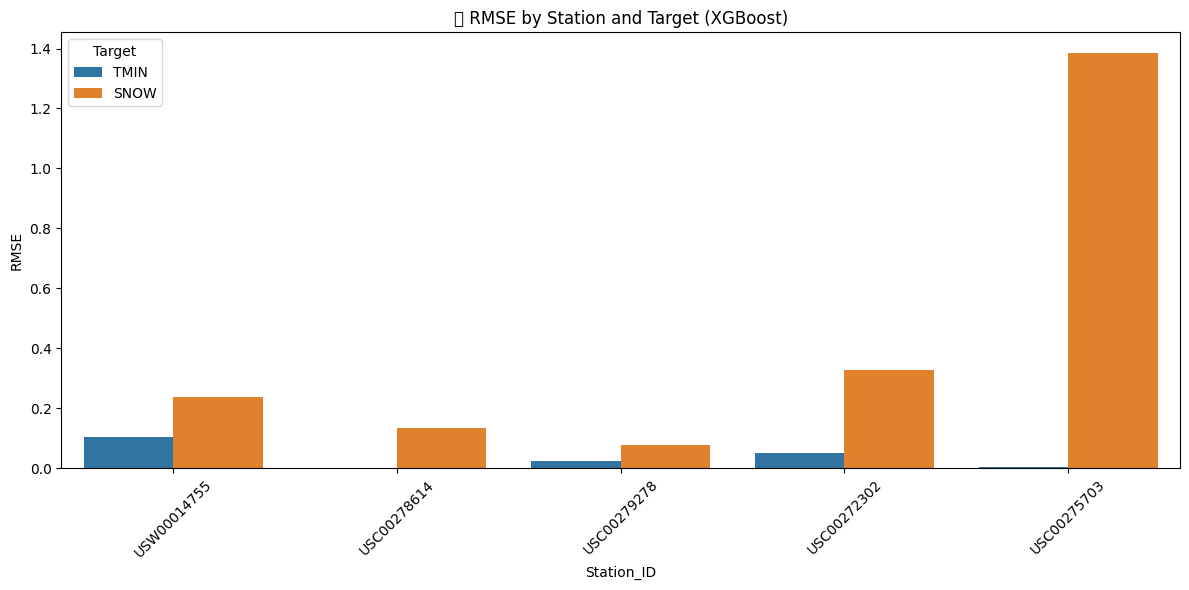

In [ ]:
for metric in ["MAE", "RMSE"]:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=xgb_df, x='Station_ID', y=metric, hue='Target')
    plt.title(f"📍 {metric} by Station and Target (XGBoost)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [ ]:
def forecast(model, input_sequence, n_steps, scaler_y):
    forecasted = []
    current_seq = input_sequence.copy()

    for _ in range(n_steps):
        pred = model.predict(current_seq[np.newaxis, :, :], verbose=0)[0, 0]
        forecasted.append(pred)

        # Add the prediction to the sequence, drop the first step
        next_input = np.append(current_seq[1:], [current_seq[-1]], axis=0)
        next_input[-1, 0] = pred  # assuming TMIN is the first feature

        current_seq = next_input

    forecasted_unscaled = scaler_y.inverse_transform(np.array(forecasted).reshape(-1, 1)).flatten()
    return forecasted_unscaled


In [ ]:
# Get last available sequence from test set
last_sequence = X_test_seq[-1]  # shape: (14, num_features)

# Predict next 7 days
n_days = 7
forecasted_tmin = forecast(best_model, last_sequence, n_days, scaler_y)

print("📅 Forecasted TMIN for next", n_days, "days:")
print(forecasted_tmin.round(2))



📅 Forecasted TMIN for next 7 days:
[ 0.47 -0.31 -0.77 -1.1  -1.3  -1.43 -1.48]


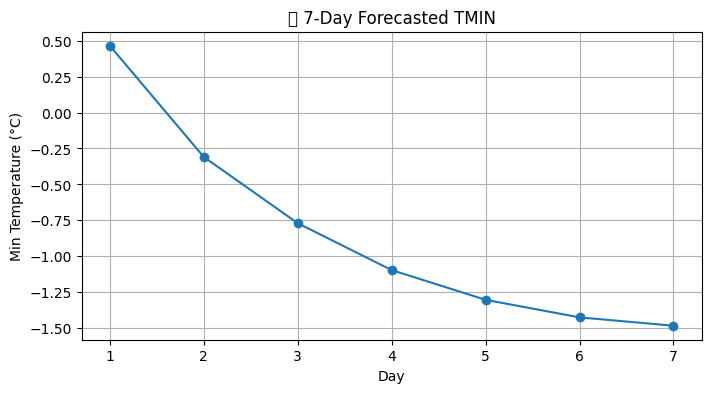

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, n_days+1), forecasted_tmin, marker='o')
plt.title('📆 7-Day Forecasted TMIN')
plt.xlabel('Day')
plt.ylabel('Min Temperature (°C)')
plt.grid(True)
plt.show()


📊 XGBoost Evaluation — MAE: 0.62 | RMSE: 0.81


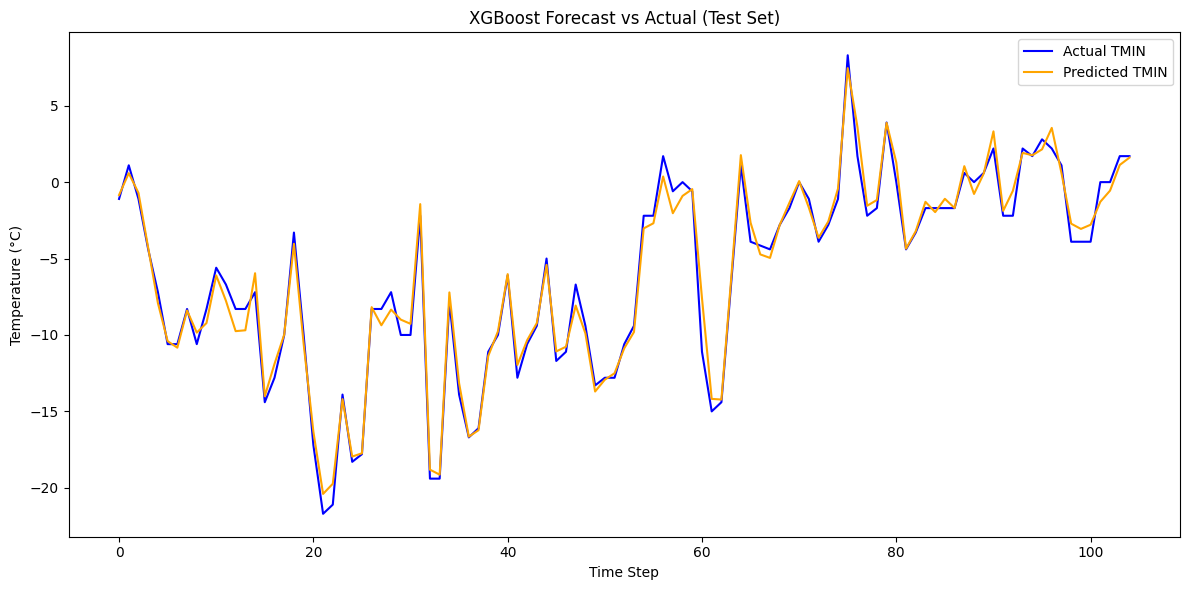

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# 1️⃣ Load data
df = pd.read_csv('/workspaces/BlizzardX/Data/feature_data.csv')
df = df[df['Station_ID'] == 'USC00279278']
df = df.dropna().sort_values('DATE')

# 2️⃣ Features & Target
#features = [
 #   'TMIN', 'TMAX', 'PRCP', 'SNOW', 'SNWD',
  #  'Rolling_Mean_TMIN_7', 'Rolling_Mean_TMIN_30', 'Seasonal_TMIN_Anomaly',
 #   'TMIN_Lag1', 'PRCP_Lag1', 'Cumulative_Precipitation_7',
 #   'Day_of_Year', 'Month'
#]

features = [
    'TMAX', 'PRCP', 'SNOW', 'SNWD',
    'Rolling_Mean_TMIN_7', 'Rolling_Mean_TMIN_30',
    'Seasonal_TMIN_Anomaly', 'TMIN_Lag1', 'PRCP_Lag1',
    'Cumulative_Precipitation_7', 'Day_of_Year', 'Month'
]

target = 'TMIN'

# 3️⃣ Split: train (<= year -3), val/test (last 3 years)
df['DATE'] = pd.to_datetime(df['DATE'])
df['Year'] = df['DATE'].dt.year

max_year = df['Year'].max()
train = df[df['Year'] <= max_year - 3]
val = df[df['Year'].isin([max_year - 2, max_year - 1])]
test = df[df['Year'] == max_year]

X_train, y_train = train[features], train[target]
X_val, y_val = val[features], val[target]
X_test, y_test = test[features], test[target]

# 4️⃣ Scaling (optional for XGBoost but good for consistency)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# 5️⃣ Train XGBoost
xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
xgb.fit(X_train_scaled, y_train)

# 6️⃣ Predict
y_pred = xgb.predict(X_test_scaled)

# 7️⃣ Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"📊 XGBoost Evaluation — MAE: {mae:.2f} | RMSE: {rmse:.2f}")

# 8️⃣ Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual TMIN', color='blue')
plt.plot(y_pred, label='Predicted TMIN', color='orange')
plt.title('XGBoost Forecast vs Actual (Test Set)')
plt.xlabel('Time Step')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Get LSTM test predictions
y_lstm_pred_scaled = best_model.predict(X_test_seq)
y_lstm_pred = scaler_y.inverse_transform(y_lstm_pred_scaled)
y_actual = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1))  # actual TMIN

# Get XGBoost test predictions
y_xgb_pred = xgb.predict(X_test_scaled).reshape(-1, 1)

# Align lengths (LSTM uses sequence trimming)
start = len(y_xgb_pred) - len(y_lstm_pred)
y_actual = y_actual[start:]
y_xgb_pred = y_xgb_pred[start:]


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  


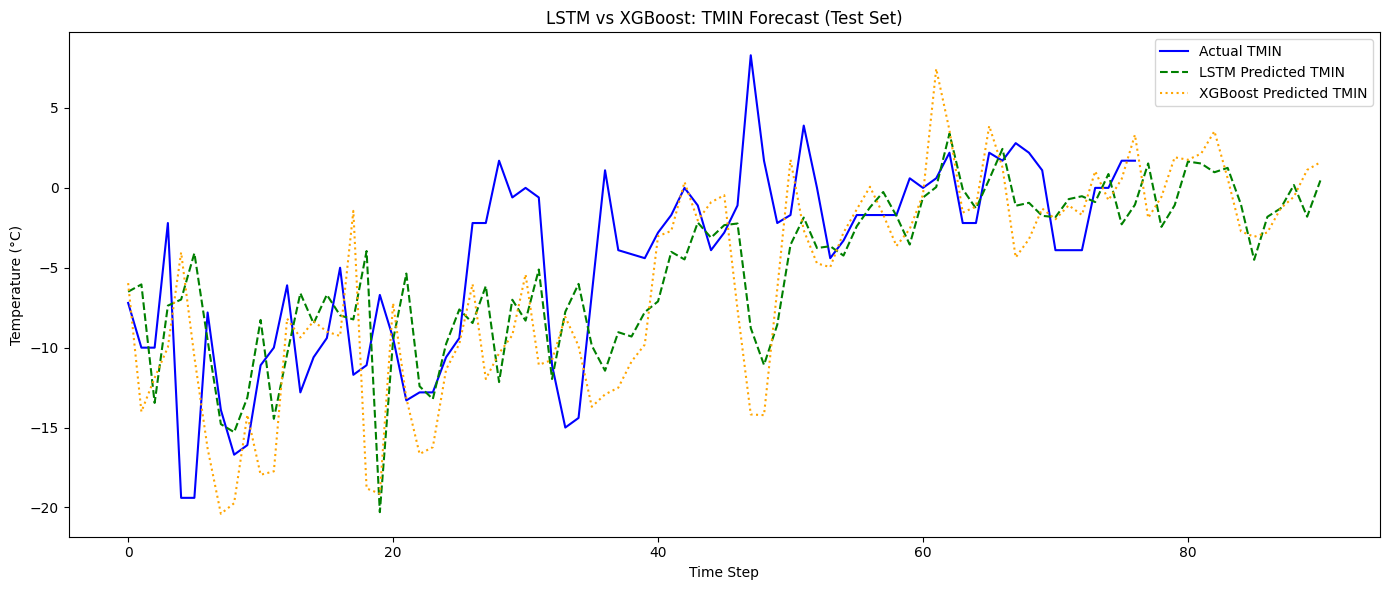

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(y_actual, label='Actual TMIN', color='blue')
plt.plot(y_lstm_pred, label='LSTM Predicted TMIN', color='green', linestyle='dashed')
plt.plot(y_xgb_pred, label='XGBoost Predicted TMIN', color='orange', linestyle='dotted')
plt.title('LSTM vs XGBoost: TMIN Forecast (Test Set)')
plt.xlabel('Time Step')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Load your current data
df = pd.read_csv('/workspaces/BlizzardX/Data/feature_data.csv')

# Ensure date format
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE')

# Add SNOW lag and rolling features
df['SNOW_Lag1'] = df['SNOW'].shift(1)
df['Rolling_Mean_SNOW_7'] = df['SNOW'].rolling(window=7).mean()

# Drop any resulting NA values
df.dropna(inplace=True)

# Save the updated file
df.to_csv('/workspaces/BlizzardX/Data/feature_data.csv', index=False)

print("✅ Updated feature_data.csv with SNOW lag/rolling features.")


✅ Updated feature_data.csv with SNOW lag/rolling features.


📊 XGBoost SNOW — MAE: 6.15 | RMSE: 16.98


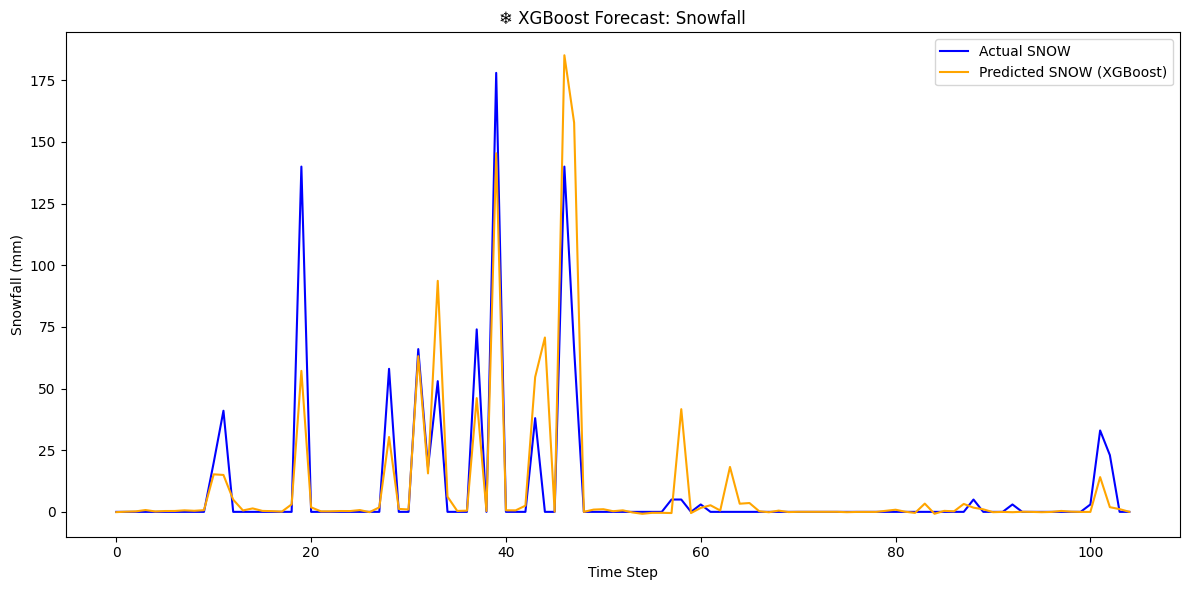

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# 1️⃣ Load Data
df = pd.read_csv('/workspaces/BlizzardX/Data/feature_data.csv')
df = df[df['Station_ID'] == 'USC00279278']
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE').dropna()
df['Year'] = df['DATE'].dt.year

# 2️⃣ Target & Features
target = 'SNOW'
features = [
    'TMAX', 'TMIN', 'PRCP', 'SNWD',
    'Rolling_Mean_SNOW_7', 'SNOW_Lag1',
    'Cumulative_Precipitation_7', 'Day_of_Year', 'Month'
]

# 3️⃣ Time Split
max_year = df['Year'].max()
train = df[df['Year'] <= max_year - 3]
val = df[df['Year'].isin([max_year - 2, max_year - 1])]
test = df[df['Year'] == max_year]

X_train, y_train = train[features], train[target]
X_val, y_val = val[features], val[target]
X_test, y_test = test[features], test[target]

# 4️⃣ Scale
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# 5️⃣ Train XGBoost
model = XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=5, random_state=42)
model.fit(X_train_scaled, y_train)

# 6️⃣ Predict & Evaluate
y_pred = model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"📊 XGBoost SNOW — MAE: {mae:.2f} | RMSE: {rmse:.2f}")

# 7️⃣ Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual SNOW', color='blue')
plt.plot(y_pred, label='Predicted SNOW (XGBoost)', color='orange')
plt.title('❄️ XGBoost Forecast: Snowfall')
plt.xlabel('Time Step')
plt.ylabel('Snowfall (mm)')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Input
import keras_tuner as kt
from keras_tuner import Objective
import matplotlib.pyplot as plt
import tensorflow as tf

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# 1️⃣ Load data
df = pd.read_csv('/workspaces/BlizzardX/Data/feature_data.csv')
df['DATE'] = pd.to_datetime(df['DATE'])
df = df[df['Station_ID'] == 'USC00279278'].dropna().sort_values('DATE')
df['Year'] = df['DATE'].dt.year

# 2️⃣ Set target & feature columns
target = 'SNOW'
initial_features = [
    'TMAX', 'TMIN', 'PRCP', 'SNWD',
    'Rolling_Mean_SNOW_7', 'SNOW_Lag1',
    'Cumulative_Precipitation_7', 'Day_of_Year', 'Month'
]

# 3️⃣ Feature selection using ExtraTrees
X_feat_check = df[initial_features]
y_feat_check = df[target]
etr = ExtraTreesRegressor(n_estimators=100, random_state=42)
etr.fit(X_feat_check, y_feat_check)
importances = etr.feature_importances_
filtered_features = pd.Series(importances, index=initial_features)
filtered_features = filtered_features[filtered_features > 0.02].index.tolist()

# 4️⃣ Train/Val/Test split
max_year = df['Year'].max()
train = df[df['Year'] <= max_year - 3]
val = df[df['Year'].isin([max_year - 2, max_year - 1])]
test = df[df['Year'] == max_year]

X_train, y_train = train[filtered_features], train[target]
X_val, y_val = val[filtered_features], val[target]
X_test, y_test = test[filtered_features], test[target]

# 5️⃣ Scale features and target
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

# 6️⃣ Create sequences
def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

seq_len = 14
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, seq_len)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, seq_len)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, seq_len)

# 7️⃣ Define and tune LSTM model
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(seq_len, len(filtered_features))))
    for i in range(hp.Int("num_lstm_layers", 1, 2)):
        model.add(LSTM(units=hp.Int(f"lstm_units_{i}", 32, 128, step=32),
                       return_sequences=(i != hp.get("num_lstm_layers") - 1)))
        model.add(Dropout(hp.Float(f"dropout_{i}", 0.1, 0.3, step=0.1)))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer=tf.keras.optimizers.Adam(hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])),
                  loss='mse', metrics=['mae'])
    return model

tuner = kt.BayesianOptimization(
    build_model,
    objective=Objective("val_loss", direction="min"),
    max_trials=8,
    executions_per_trial=1,
    directory="lstm_tuner_snow",
    project_name="snow_lstm"
)

train_ds = tf.data.Dataset.from_tensor_slices((X_train_seq, y_train_seq)).batch(16).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val_seq, y_val_seq)).batch(16).prefetch(tf.data.AUTOTUNE)

tuner.search(train_ds, validation_data=val_ds, epochs=30,
             callbacks=[EarlyStopping(patience=5, restore_best_weights=True)], verbose=1)

# 8️⃣ Final model
best_model = tuner.get_best_models(num_models=1)[0]
eval_results = best_model.evaluate(X_test_seq, y_test_seq)
print("📊 LSTM Snow Evaluation:", dict(zip(best_model.metrics_names, eval_results)))


Reloading Tuner from lstm_tuner_snow/snow_lstm/tuner0.json
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.5988 - mae: 0.6842 
📊 LSTM Snow Evaluation: {'loss': 1.1688154935836792, 'compile_metrics': 0.5436477661132812}


In [ ]:
def forecast_lstm(model, last_seq, n_days, scaler_y):
    preds = []
    current_seq = last_seq.copy()
    for _ in range(n_days):
        pred_scaled = model.predict(current_seq[np.newaxis, :, :])[0, 0]
        pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
        preds.append(pred)
        new_entry = np.append(current_seq[1:], [current_seq[-1]], axis=0)  # placeholder update
        new_entry[-1][-1] = pred_scaled  # inject predicted snow into SNOW_Lag1
        current_seq = new_entry
    return np.array(preds)


In [ ]:
last_seq = X_test_seq[-1]
forecasted_snow = forecast_lstm(best_model, last_seq, 7, scaler_y)
print("❄️ Forecasted Snow for Next 7 Days:\n", forecasted_snow.round(2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
❄️ Forecasted Snow for Next 7 Days:
 [-2.   -0.86 -1.22 -1.29 -1.31 -0.88 -0.67]


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 


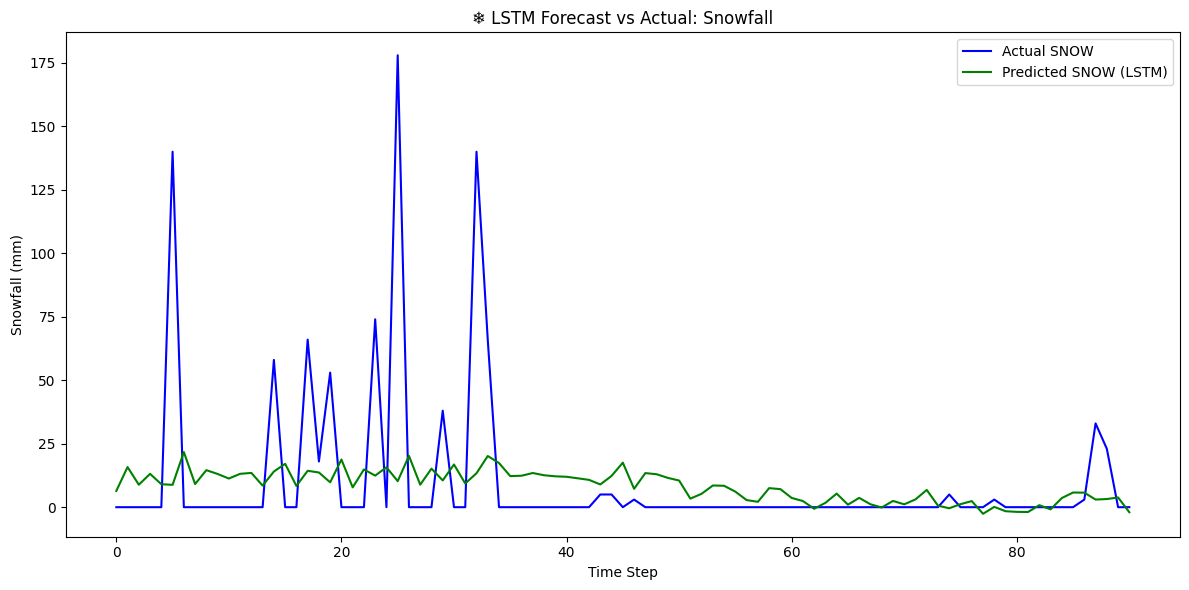

In [ ]:
y_pred_scaled = best_model.predict(X_test_seq)
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_true = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

plt.figure(figsize=(12, 6))
plt.plot(y_true, label='Actual SNOW', color='blue')
plt.plot(y_pred, label='Predicted SNOW (LSTM)', color='green')
plt.title('❄️ LSTM Forecast vs Actual: Snowfall')
plt.xlabel('Time Step')
plt.ylabel('Snowfall (mm)')
plt.legend()
plt.tight_layout()
plt.show()


Fitting 3 folds for each of 15 candidates, totalling 45 fits

📊 Best Params: {'subsample': 1.0, 'n_estimators': 150, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
✅ MAE: 0.003 | RMSE: 0.0249


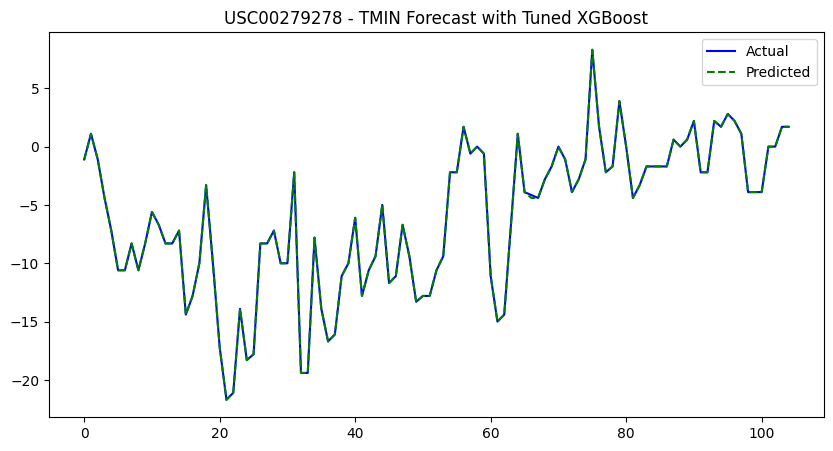

In [ ]:
# Phase 2: Hyperparameter Tuning with RandomizedSearchCV for one station

import pandas as pd
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Load feature data
df = pd.read_csv('/workspaces/BlizzardX/Data/feature_data.csv')
df['DATE'] = pd.to_datetime(df['DATE'])
df['Year'] = df['DATE'].dt.year

# Choose a sample station and target
station_id = "USC00279278"
target = "TMIN"

# Define features per target
features = [
    'TMIN', 'TMAX', 'PRCP', 'SNOW', 'SNWD',
    'Rolling_Mean_TMIN_7', 'Rolling_Mean_TMIN_30', 'Seasonal_TMIN_Anomaly',
    'TMIN_Lag1', 'PRCP_Lag1', 'Cumulative_Precipitation_7',
    'Day_of_Year', 'Month'
] if target == "TMIN" else [
    'TMIN', 'TMAX', 'PRCP', 'SNOW', 'SNWD',
    'Rolling_Mean_SNOW_7', 'SNOW_Lag1', 'Day_of_Year', 'Month'
]

# Filter station data
data = df[df['Station_ID'] == station_id].dropna().sort_values('DATE')

# Time-based split
max_year = data['Year'].max()
train = data[data['Year'] <= max_year - 3]
test = data[data['Year'] == max_year]

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# Scale features
gs_X = StandardScaler()
gs_y = StandardScaler()
X_train_scaled = gs_X.fit_transform(X_train)
X_test_scaled = gs_X.transform(X_test)
y_train_scaled = gs_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()

# Define parameter grid
param_grid = {
    "n_estimators": [100, 150, 200],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

# Setup search
tuner = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=15,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# Run tuning
tuner.fit(X_train_scaled, y_train_scaled)

# Best model
best_model = tuner.best_estimator_
y_pred_scaled = best_model.predict(X_test_scaled)
y_pred = gs_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("\n📊 Best Params:", tuner.best_params_)
print("✅ MAE:", round(mae, 4), "| RMSE:", round(rmse, 4))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label="Actual", color='blue')
plt.plot(y_pred, label="Predicted", color='green', linestyle='--')
plt.title(f"{station_id} - {target} Forecast with Tuned XGBoost")
plt.legend()
plt.show()


In [ ]:
#Loop over all stations_Tune for both TMIN and SNOW
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import joblib
import os

# Load feature data
df = pd.read_csv("/workspaces/BlizzardX/Data/feature_data.csv")
df['DATE'] = pd.to_datetime(df['DATE'])
df['Year'] = df['DATE'].dt.year

# Output directory setup
output_dir = "//workspaces/BlizzardX/Data/XGB_Tuned_Models"
os.makedirs(output_dir, exist_ok=True)

# Targets and corresponding feature sets
target_feature_map = {
    "TMIN": [
        'TMIN', 'TMAX', 'PRCP', 'SNOW', 'SNWD',
        'Rolling_Mean_TMIN_7', 'Rolling_Mean_TMIN_30', 'Seasonal_TMIN_Anomaly',
        'TMIN_Lag1', 'PRCP_Lag1', 'Cumulative_Precipitation_7',
        'Day_of_Year', 'Month'
    ],
    "SNOW": [
        'TMIN', 'TMAX', 'PRCP', 'SNOW', 'SNWD',
        'Rolling_Mean_SNOW_7', 'SNOW_Lag1',
        'Day_of_Year', 'Month'
    ]
}

# XGBoost parameter grid
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [1.0],
    'colsample_bytree': [1.0]
}

results = []
station_ids = df['Station_ID'].unique()

for target, features in target_feature_map.items():
    for station_id in station_ids:
        station_df = df[df['Station_ID'] == station_id].dropna(subset=features + [target])
        if len(station_df) < 200:
            continue

        station_df = station_df.sort_values('DATE')
        max_year = station_df['Year'].max()
        train = station_df[station_df['Year'] <= max_year - 3]
        test = station_df[station_df['Year'] == max_year]

        X_train, y_train = train[features], train[target]
        X_test, y_test = test[features], test[target]

        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        X_train_scaled = scaler_X.fit_transform(X_train)
        X_test_scaled = scaler_X.transform(X_test)
        y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()

        # GridSearchCV with 3-fold CV
        model = XGBRegressor(random_state=42)
        grid_search = GridSearchCV(model, param_grid, scoring='neg_mean_squared_error', cv=3, verbose=0)
        grid_search.fit(X_train_scaled, y_train_scaled)
        best_model = grid_search.best_estimator_

        y_pred_scaled = best_model.predict(X_test_scaled)
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        y_actual = y_test.values

        mae = mean_absolute_error(y_actual, y_pred)
        rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

        # Save model
        model_path = os.path.join(output_dir, f"{station_id}_{target}_xgb_model.pkl")
        joblib.dump(best_model, model_path)

        results.append({
            "Station_ID": station_id,
            "Target": target,
            "MAE": mae,
            "RMSE": rmse,
            "Best_Params": grid_search.best_params_,
            "Test_Sample_Count": len(y_actual)
        })

# Save all results to a DataFrame
results_df = pd.DataFrame(results)
results_csv_path = os.path.join(output_dir, "xgb_tuned_results.csv")
results_df.to_csv(results_csv_path, index=False)

results_df.head()  # or display(results_df) if you're in Jupyter



,Station_ID,Target,MAE,RMSE,Best_Params,Test_Sample_Count
0,USW00014755,TMIN,0.022268,0.103151,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",105
1,USC00278614,TMIN,0.004551,0.005788,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",105
2,USC00279278,TMIN,0.003274,0.024939,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",105
3,USC00272302,TMIN,0.009459,0.046831,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",105
4,USC00275703,TMIN,0.000892,0.003026,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",105


In [ ]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 80.1 MB/s eta 0:00:00:00:01



🔍 Explaining SHAP values for USC00279278 - TMIN


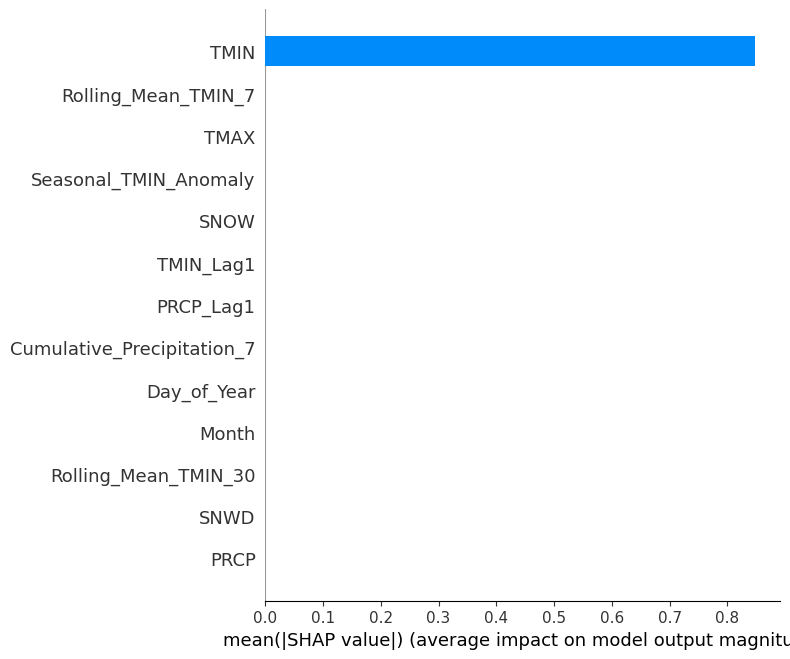

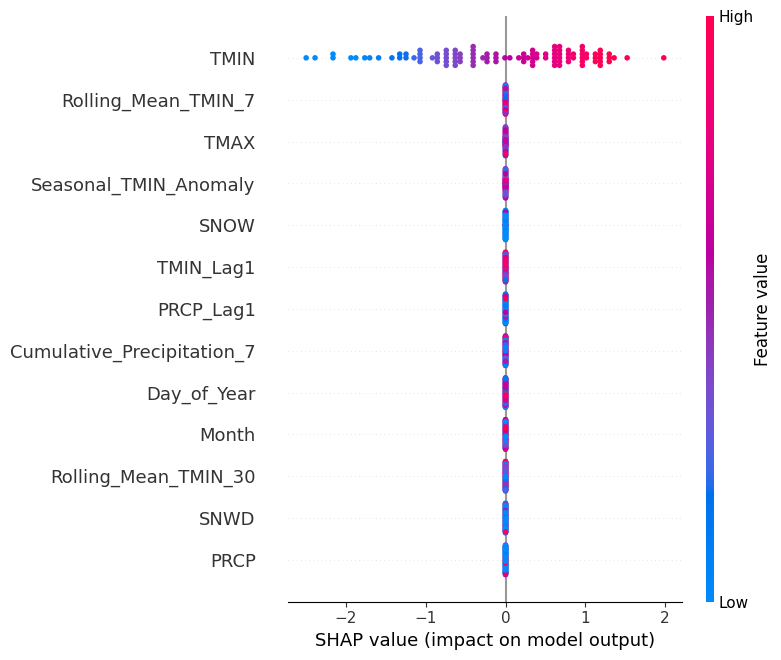


🔍 Explaining SHAP values for USC00279278 - SNOW


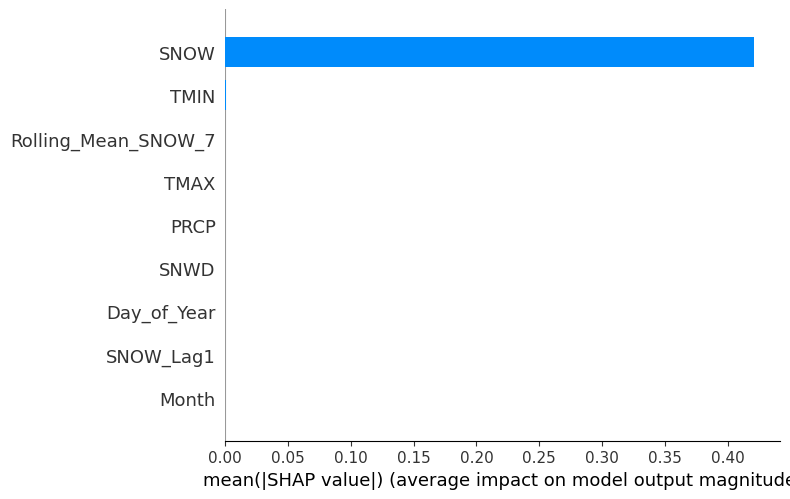

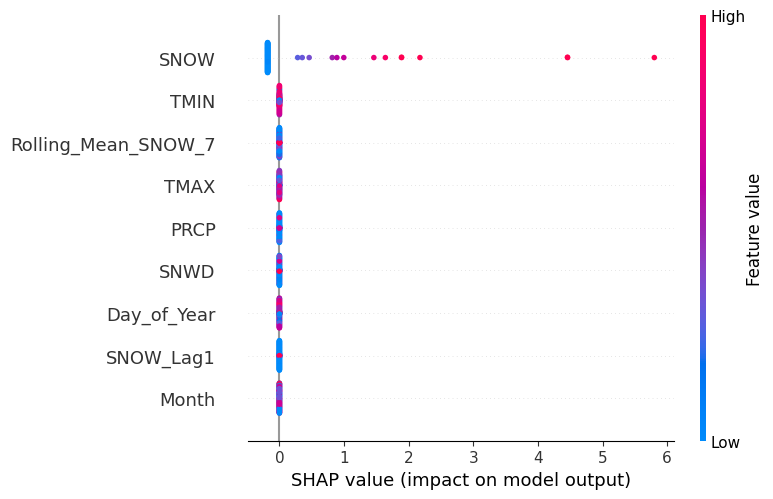

In [ ]:
# Phase 3: SHAP Explainability for Tuned XGBoost Models

import shap
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os


# Setup
model_dir = '/workspaces/BlizzardX/Data/XGB_Tuned_Models'
station_id = 'USC00279278'
targets = ['TMIN', 'SNOW']

for target in targets:
    print(f"\n🔍 Explaining SHAP values for {station_id} - {target}")

    features = [
        'TMIN', 'TMAX', 'PRCP', 'SNOW', 'SNWD',
        'Rolling_Mean_TMIN_7', 'Rolling_Mean_TMIN_30', 'Seasonal_TMIN_Anomaly',
        'TMIN_Lag1', 'PRCP_Lag1', 'Cumulative_Precipitation_7',
        'Day_of_Year', 'Month'
    ] if target == 'TMIN' else [
        'TMIN', 'TMAX', 'PRCP', 'SNOW', 'SNWD',
        'Rolling_Mean_SNOW_7', 'SNOW_Lag1', 'Day_of_Year', 'Month'
    ]

    data = df[df['Station_ID'] == station_id].dropna(subset=features + [target]).sort_values('DATE')
    max_year = data['Year'].max()
    test = data[data['Year'] == max_year]
    X_test = test[features]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_test)

    model_path = f'{model_dir}/{station_id}_{target}_xgb_model.pkl'
    model = joblib.load(model_path)

    explainer = shap.Explainer(model)
    shap_values = explainer(X_scaled)

    # SHAP summary plots
    shap.summary_plot(shap_values, X_test, plot_type='bar', show=True)
    shap.summary_plot(shap_values, X_test, plot_type='dot', show=True)
